## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_robust"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "robust"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


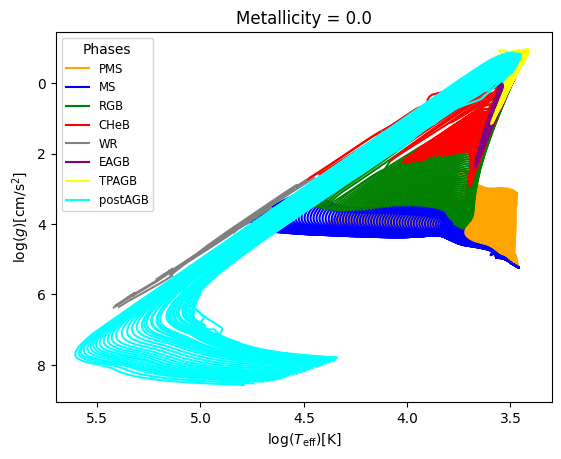

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


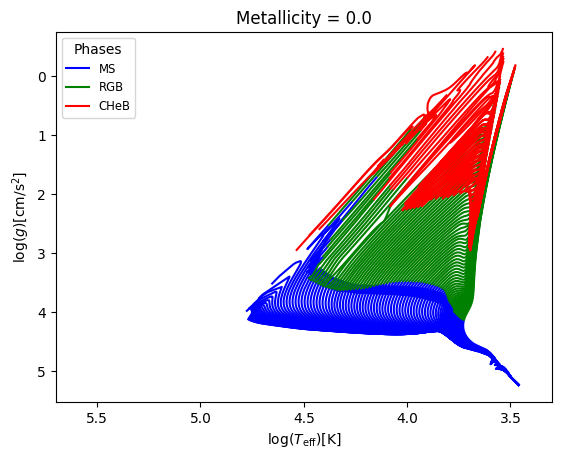

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1154, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0283, Median : 3.9761

log_g  : Range : -1.08 - 6.2594, Mean : 3.5075, Median : 3.8521

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.4145, Median : 2.8996

log_R  : Range : -1.0 - 3.1298, Mean : 0.735, Median : 0.7005



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.900660435695107
Mean value in train data for the star_mass parameter: 11.448959764246645

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999984244466985 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.89581954298918
Mean value in test data for the star_mass parameter: 11.31127918999169

Range in test data for the log_R parameter : -0.9974747647513328 - 3.1297545143214007
Median value in test data for the log_R parameter: 0.700308157259431
Mean value in test data for the log_R parameter: 0.7362027655401773

(472953, 4) (157652, 4)
(47295

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.2728709030098607
  RMSE :  22.42990012917265
  MAE :  13.107804483636013
  MedAE :  11.2530178308328
  CORR :  0.5343027371731518
  MAX_ER :  257.5084784704818
  Percentiles : 
    75th percentile :  15.423789353892992
    90th percentile :  18.517408532834068
    95th percentile :  20.73404863667008
    99th percentile :  102.34281786807927

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.31688178138922396
  RMSE :  24.543023748411922
  MAE :  10.23576274299403
  MedAE :  5.268355111684661
  CORR :  0.5956286032810741
  MAX_ER :  247.13282094138904
  Percentiles : 
    75th percentile :  11.237111436497926
    90th percentile :  14.437479891518228
    95th percentile :  23.01619817363243


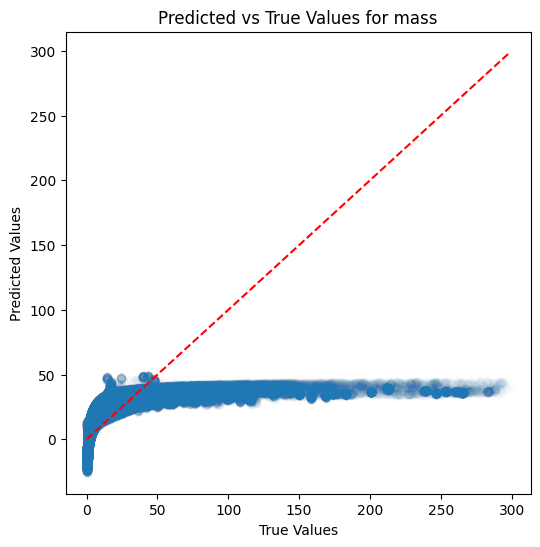

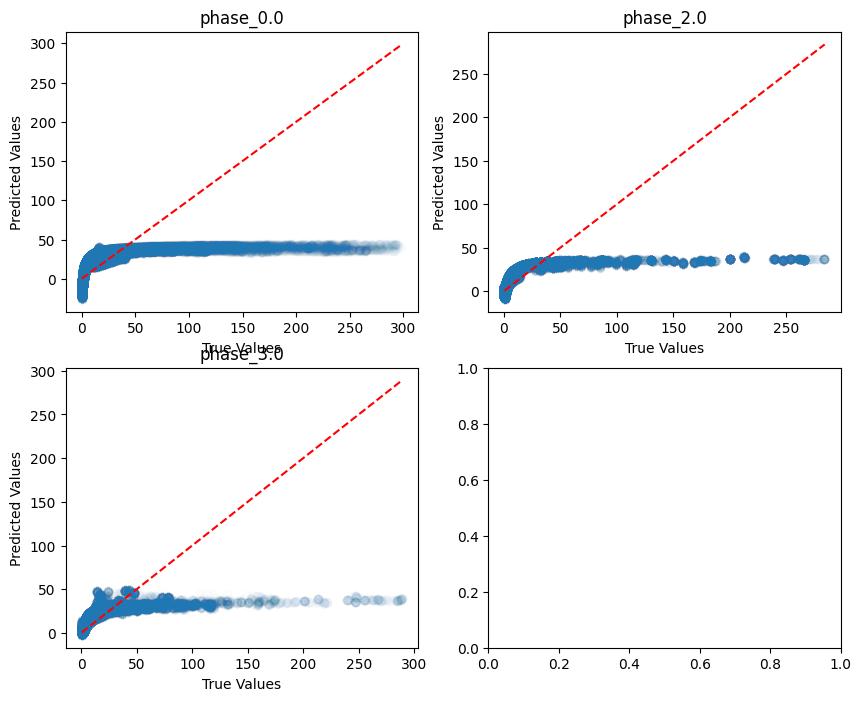

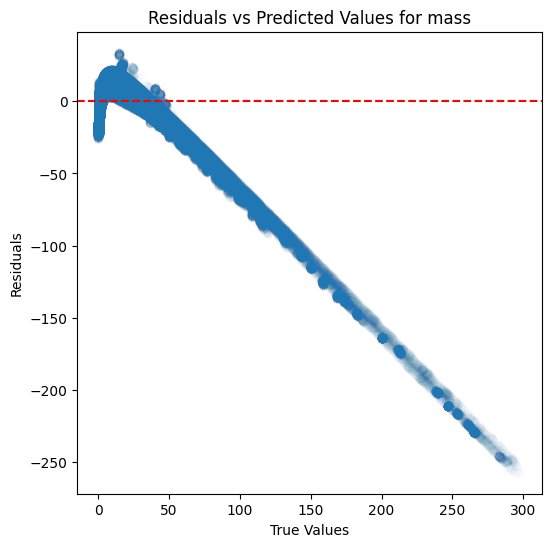

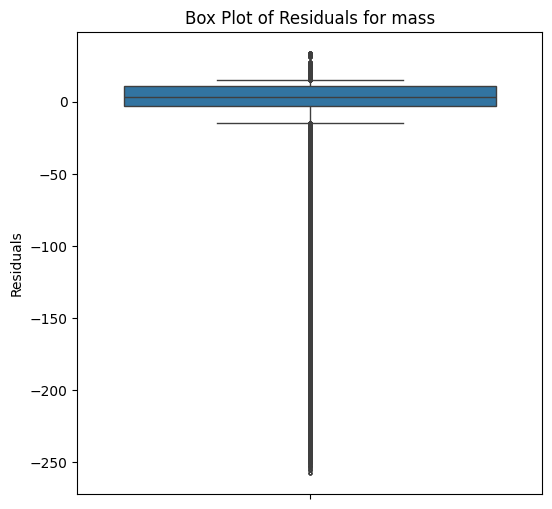

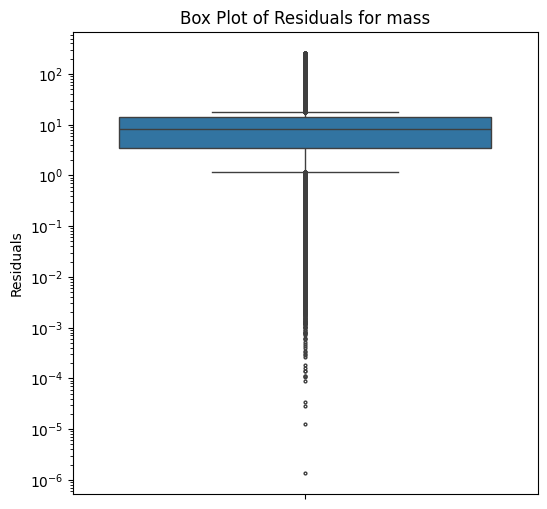

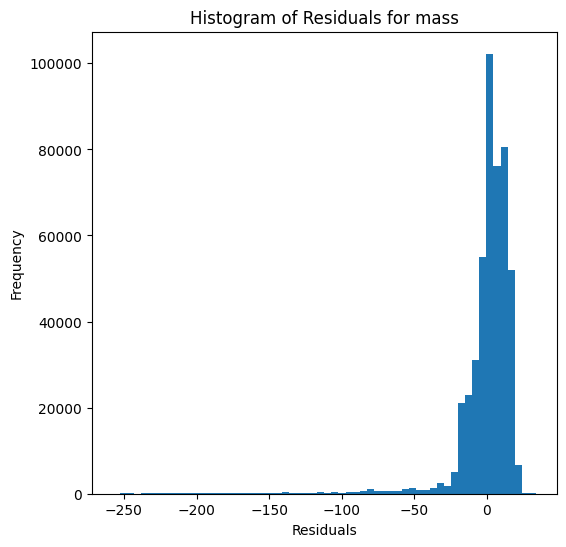

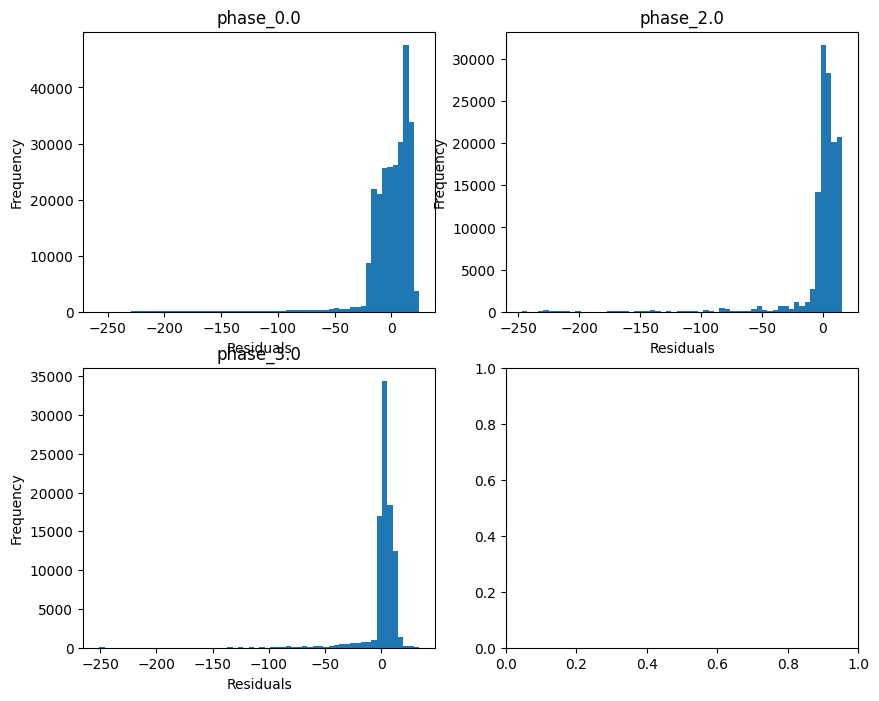

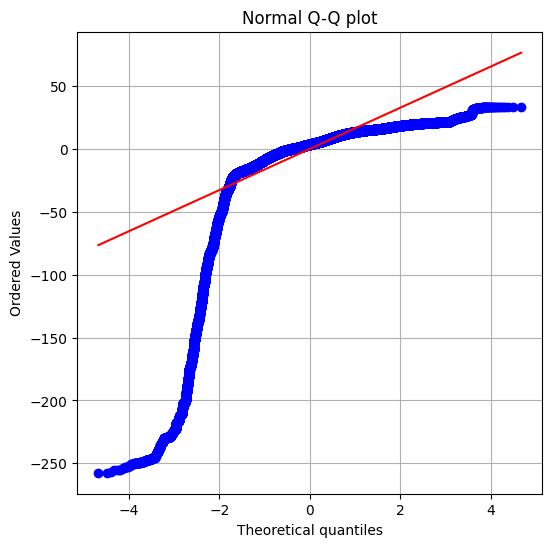

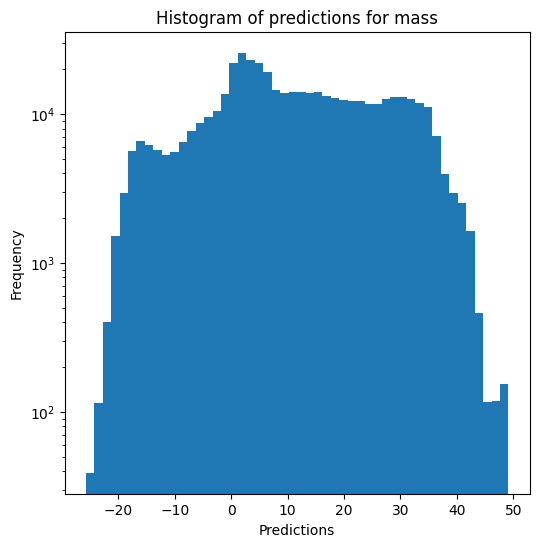

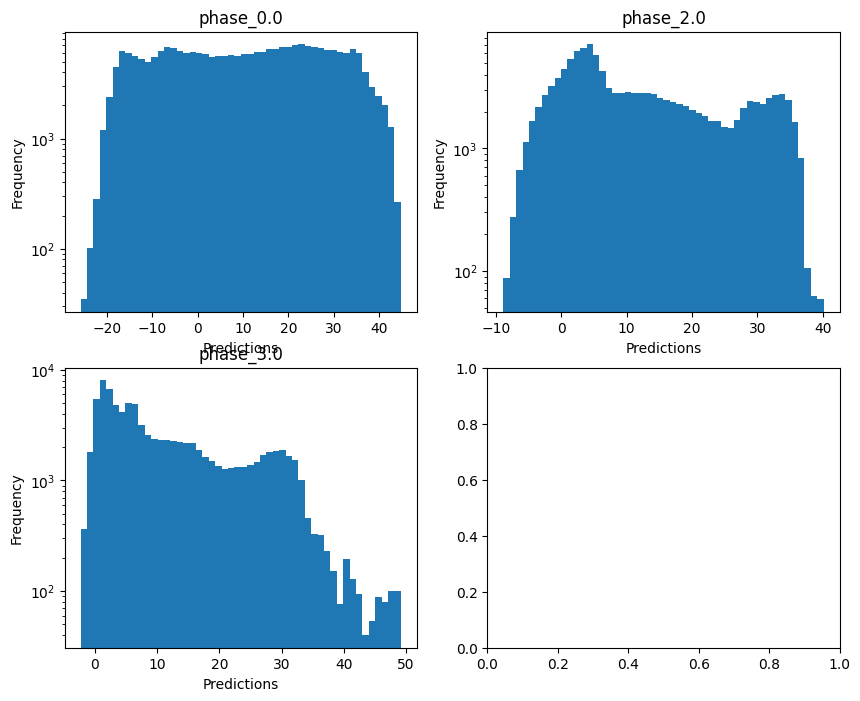

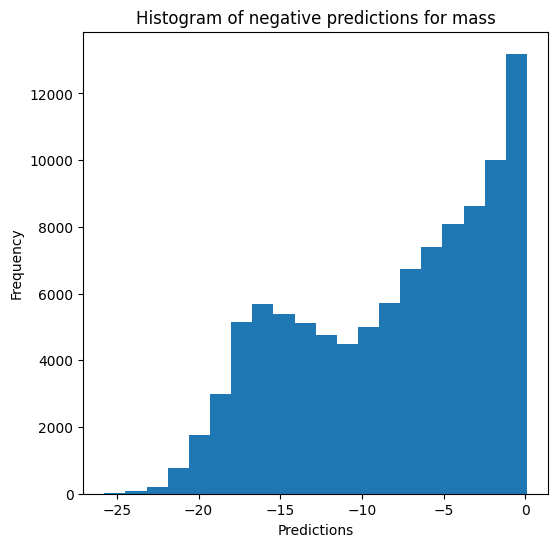


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9778146729622429
  RMSE :  0.08499169455949711
  MAE :  0.0664405767688153
  MedAE :  0.05247064416339331
  CORR :  0.9888944199376586
  MAX_ER :  0.4580776699592273
  Percentiles : 
    75th percentile :  0.09619903944969971
    90th percentile :  0.13469965074636228
    95th percentile :  0.1572795857524995
    99th percentile :  0.2505204276476836

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9679744997103417
  RMSE :  0.0884158297132111
  MAE :  0.05773662868809912
  MedAE :  0.033944377876420795
  CORR :  0.9838665758685912
  MAX_ER :  0.45290839756953316
  Percentiles : 
    75th percentile :  0.07349899037494567
    90th percentile :  0.14129835891612186
    95th percentile :  0.1940807867103965
    99th percentile :  0.350020978493058

radius results for the phase category 

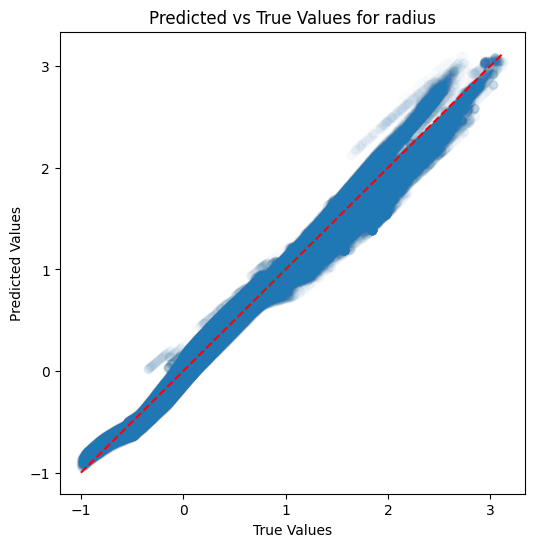

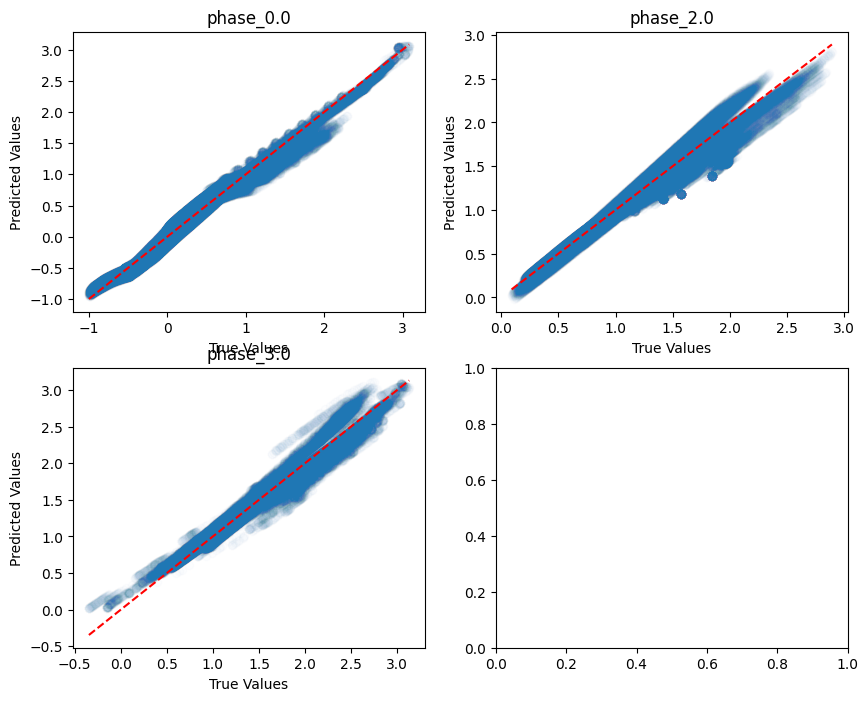

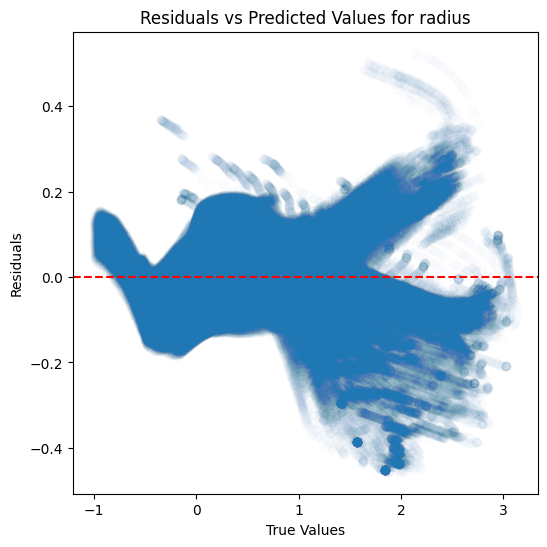

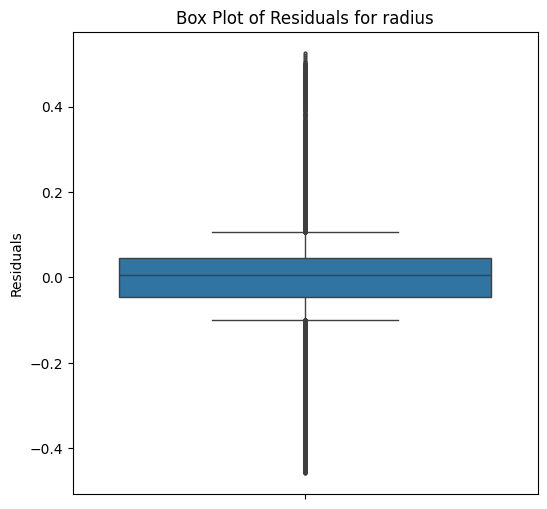

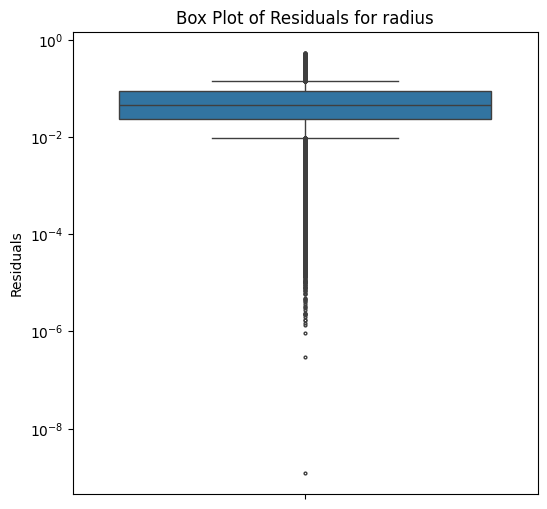

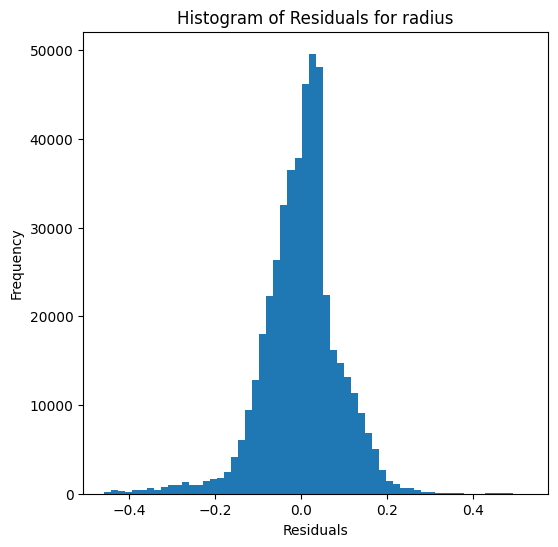

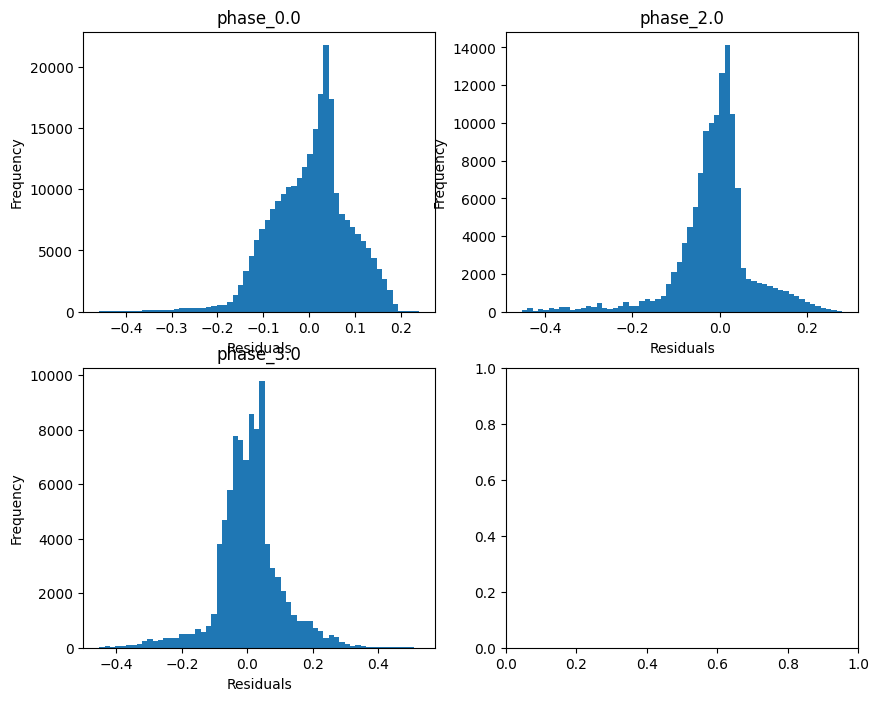

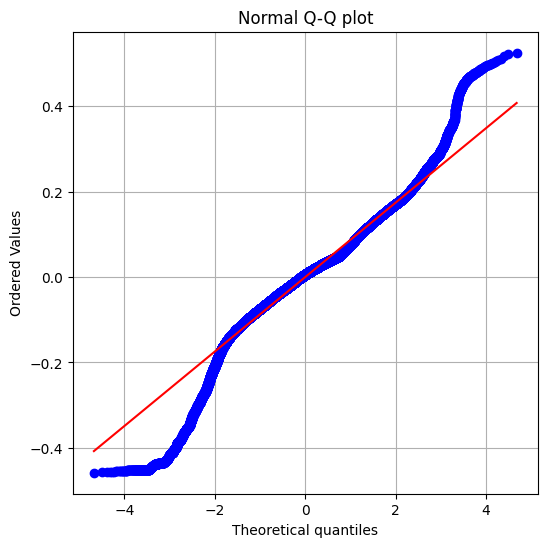

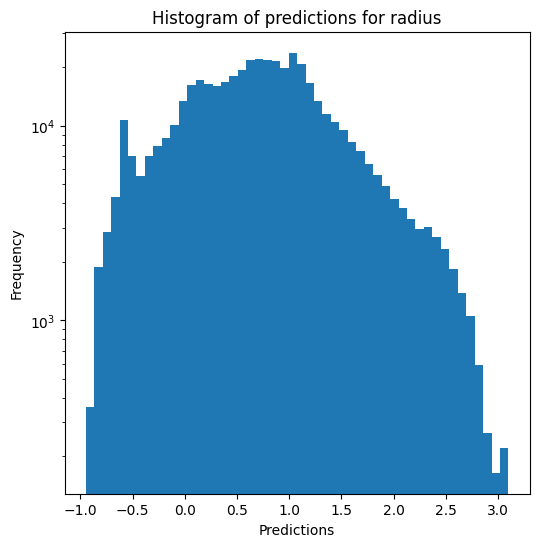

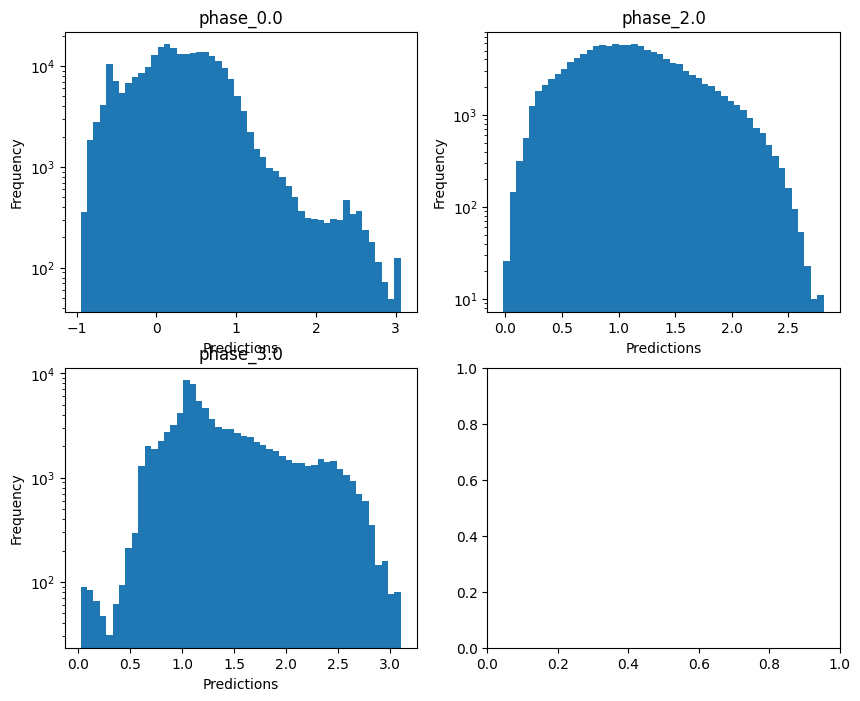

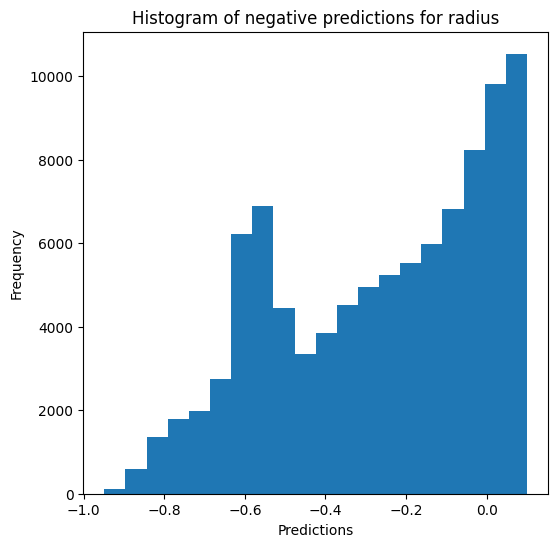

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9936721398671367
  RMSE :  2.092182814312377
  MAE :  0.2682579238445247
  MedAE :  0.005943969738096411
  CORR :  0.9968467350115852
  MAX_ER :  124.16374534338215
  Percentiles : 
    75th percentile :  0.03091367472335349
    90th percentile :  0.18496710007643036
    95th percentile :  0.6740177787943388
    99th percentile :  5.866302833303478

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9991330923578028
  RMSE :  0.8743216168168603
  MAE :  0.061868936333981606
  MedAE :  0.00035474156828474435
  CORR :  0.9995666476840903
  MAX_ER :  115.07406668861114
  Percentiles : 
    75th percentile :  0.00549863099912784
    90th percentile :  0.025452167495834566
    95th percentile :  0

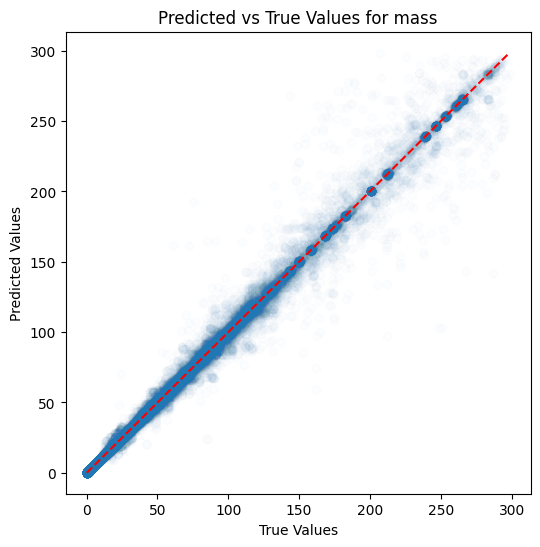

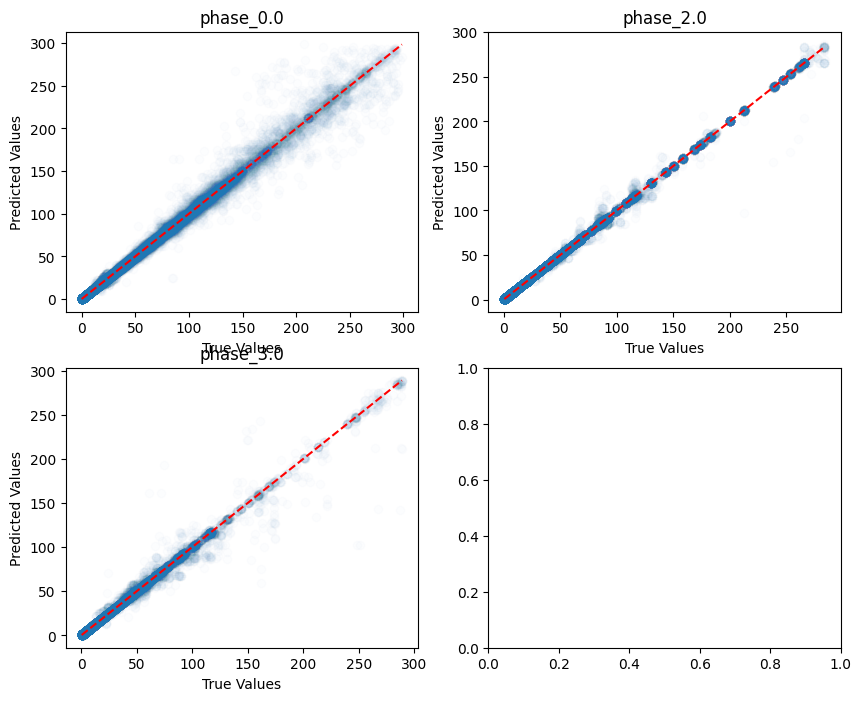

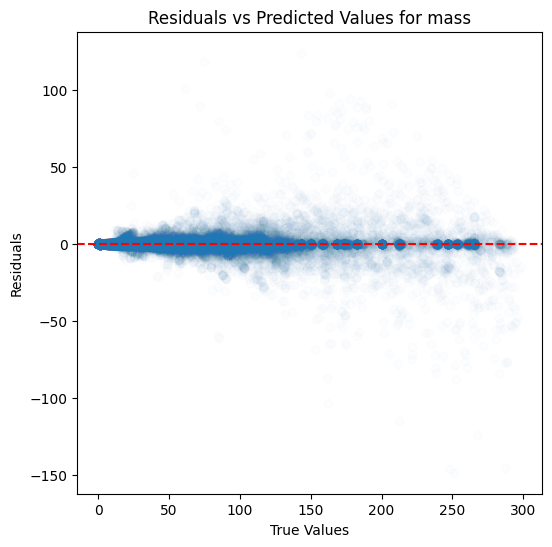

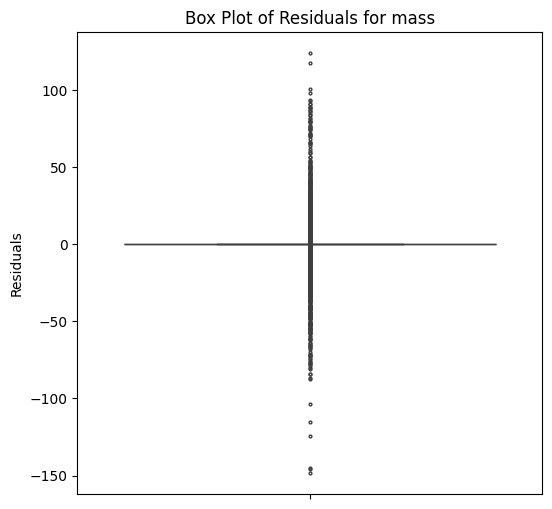

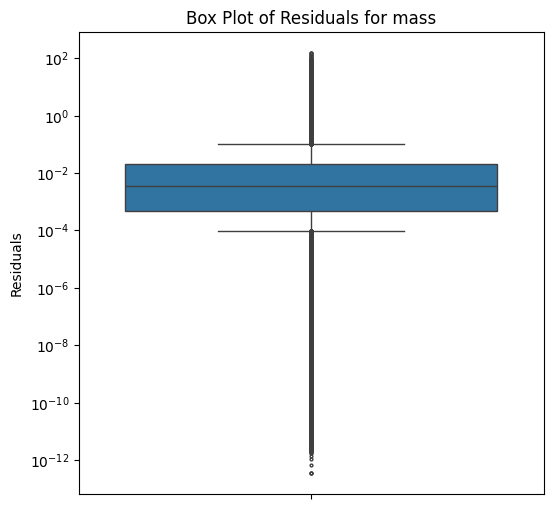

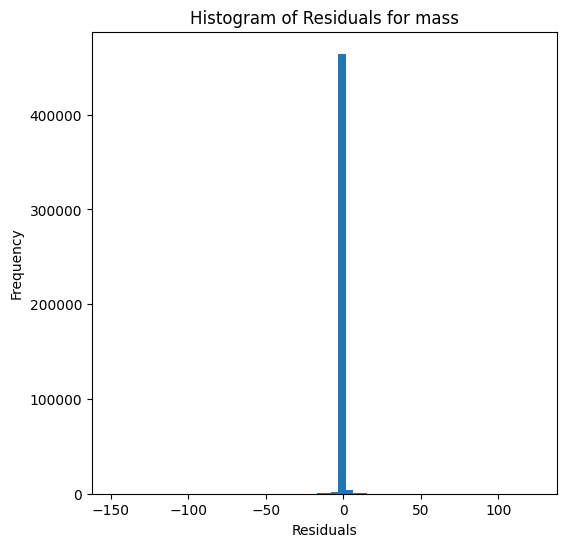

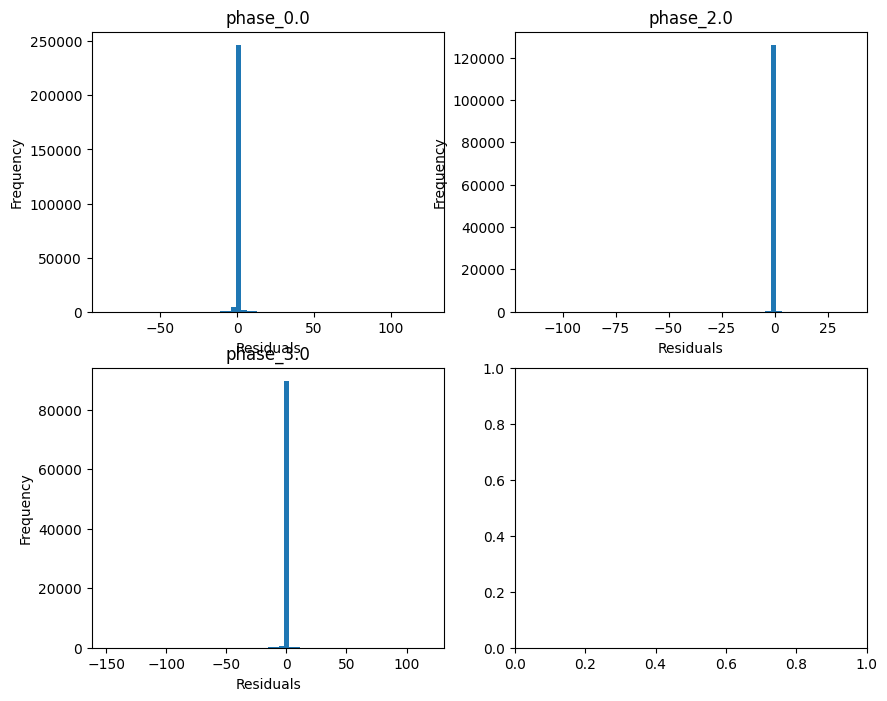

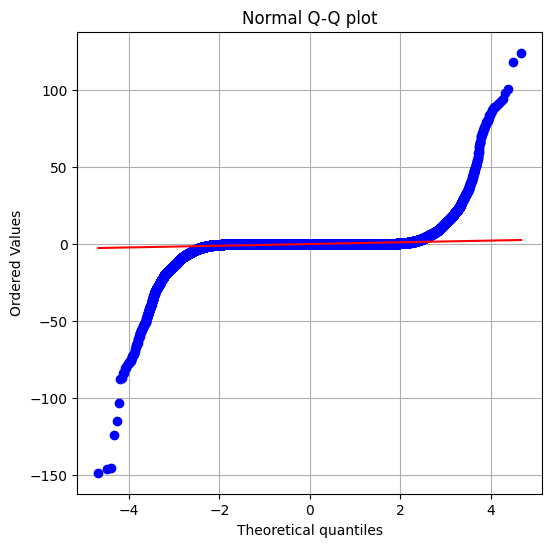

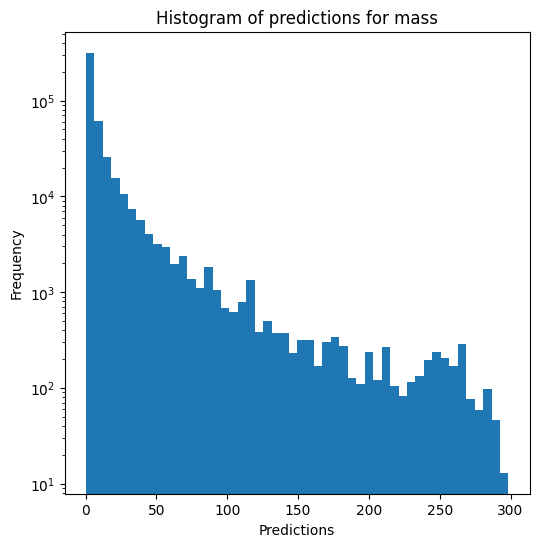

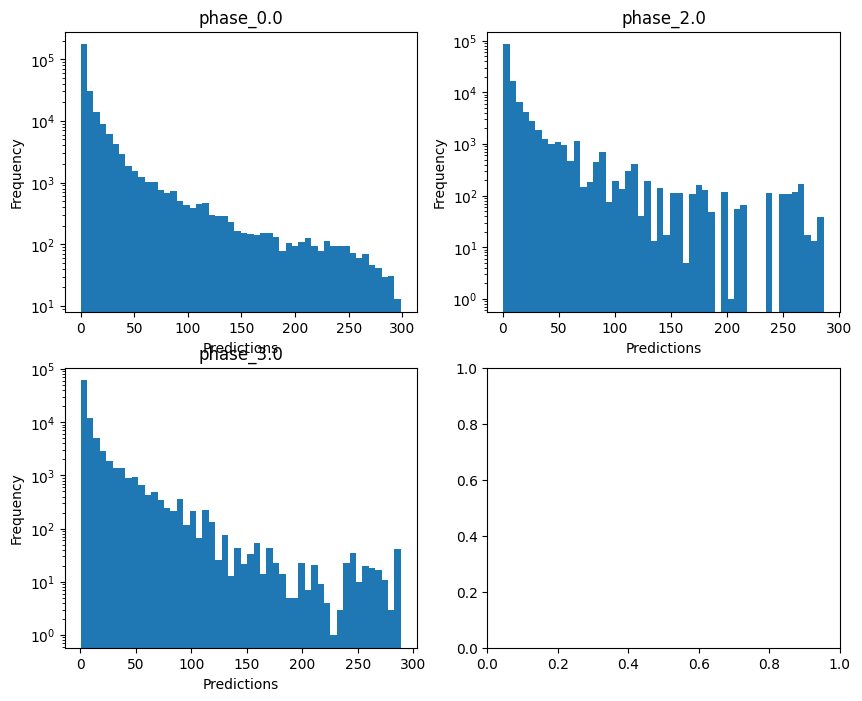

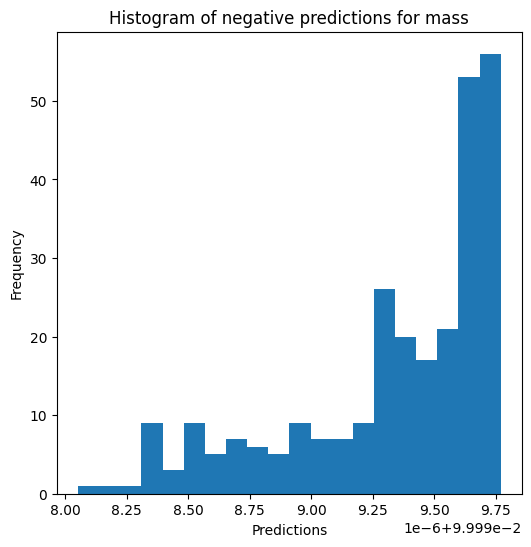


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997812953170327
  RMSE :  0.008434671026173715
  MAE :  0.004608667410416638
  MedAE :  0.0026307768750436777
  CORR :  0.9998906872539167
  MAX_ER :  0.4783497157713891
  Percentiles : 
    75th percentile :  0.005351847310182206
    90th percentile :  0.010306044575474599
    95th percentile :  0.01521234506457686
    99th percentile :  0.032298316526861603

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9995913251417556
  RMSE :  0.009927473271235599
  MAE :  0.006749829586464219
  MedAE :  0.0052124261025310314
  CORR :  0.9997969141293508
  MAX_ER :  0.2623505527794312
  Percentiles : 
    75th percentile :  0.009065629931874042
    90th percentile :  0.013452226002676593
    95th percentile :  0.016635426600504318
    99th percentile :  0.03191777435387874

radius results for 

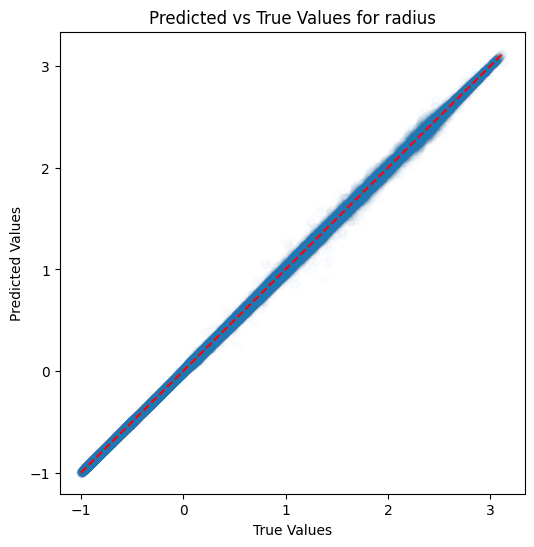

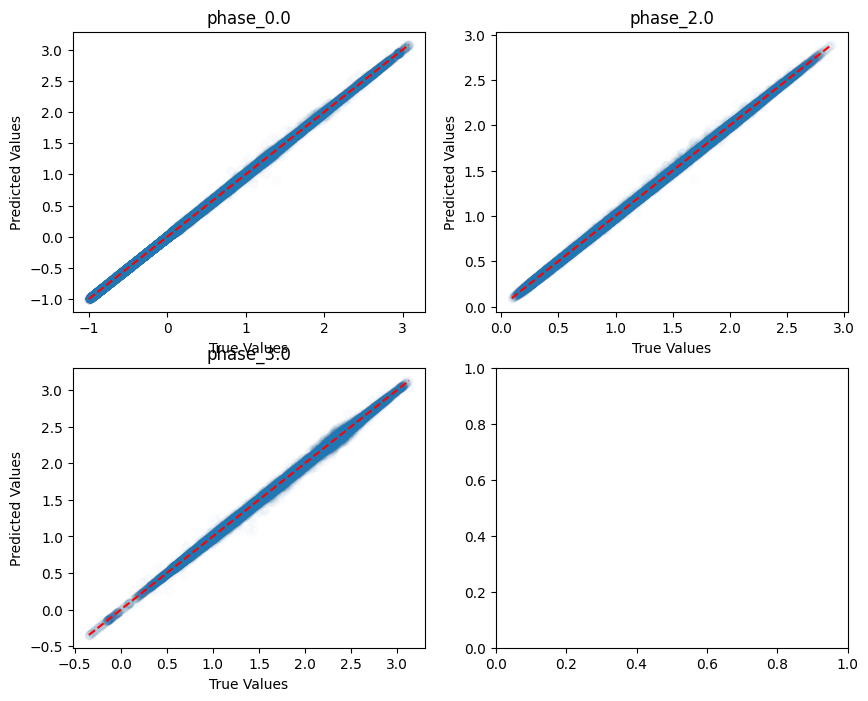

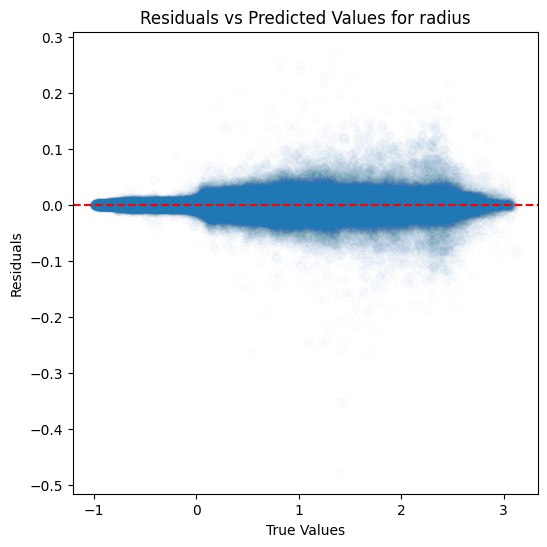

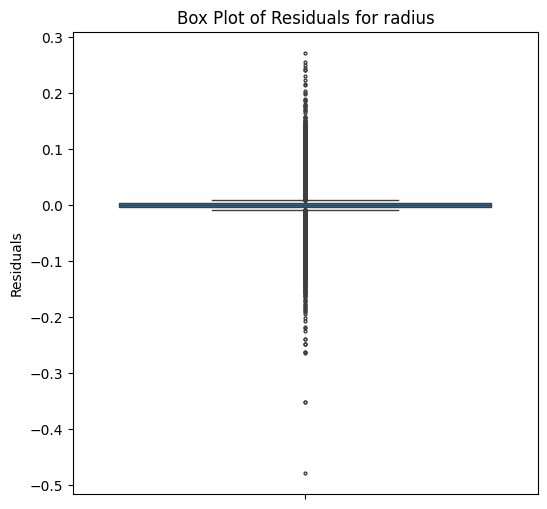

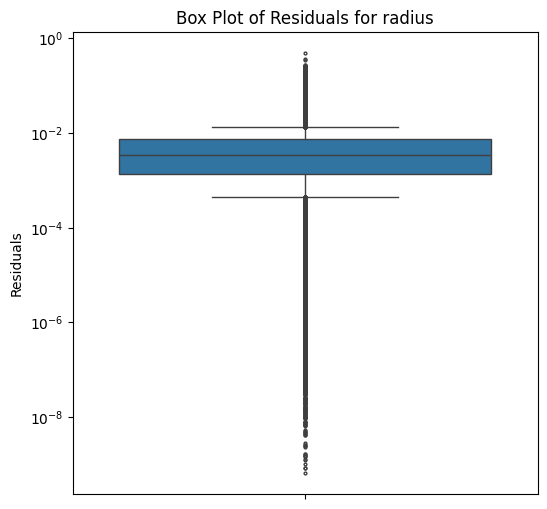

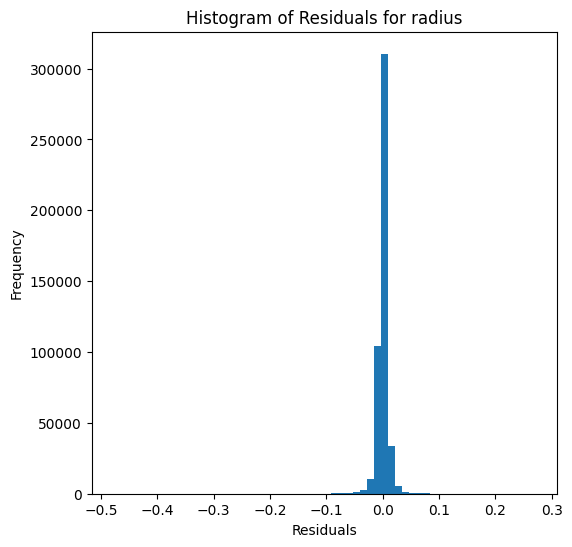

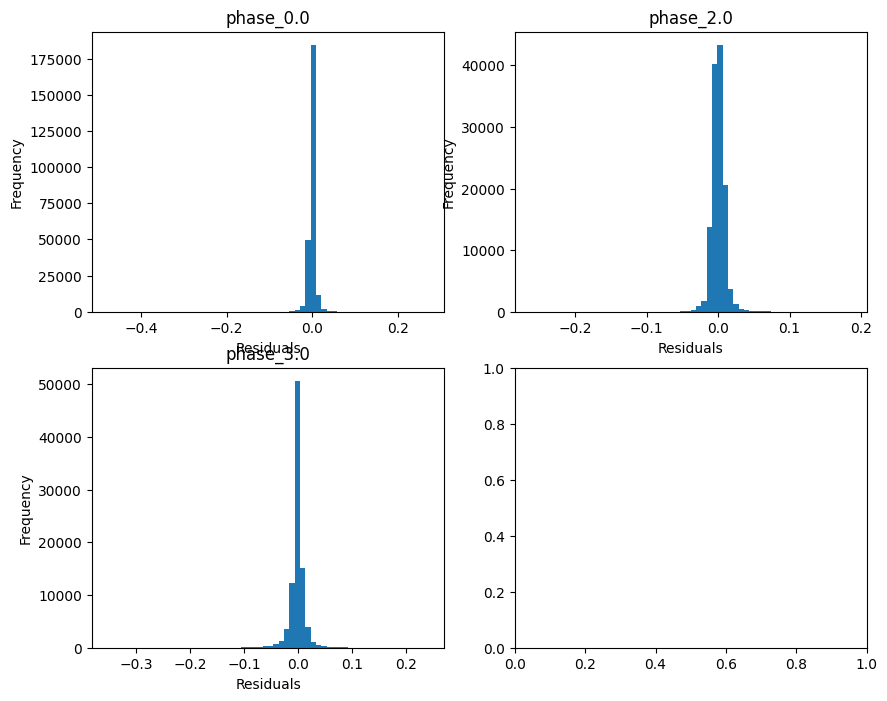

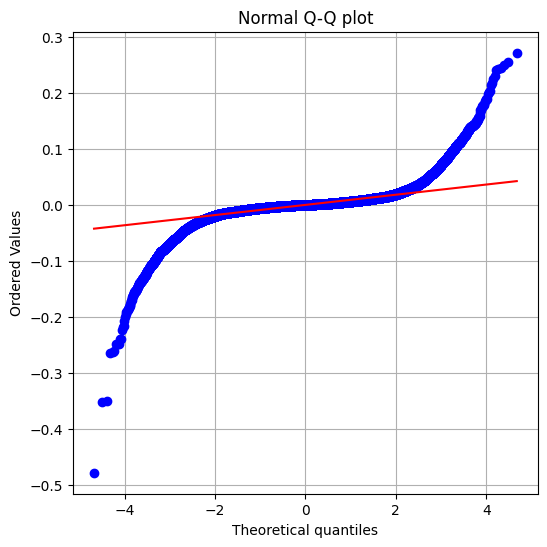

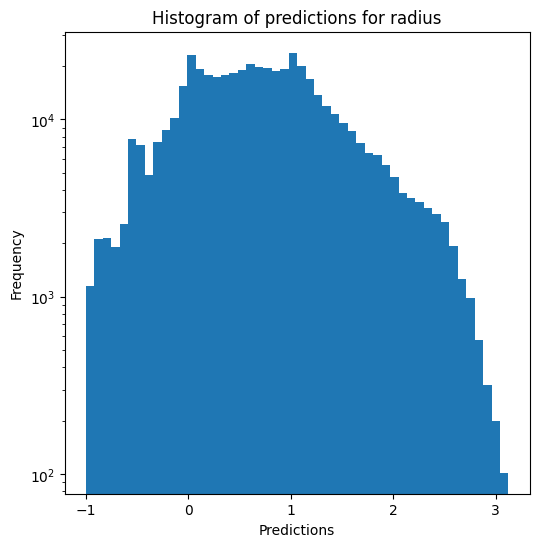

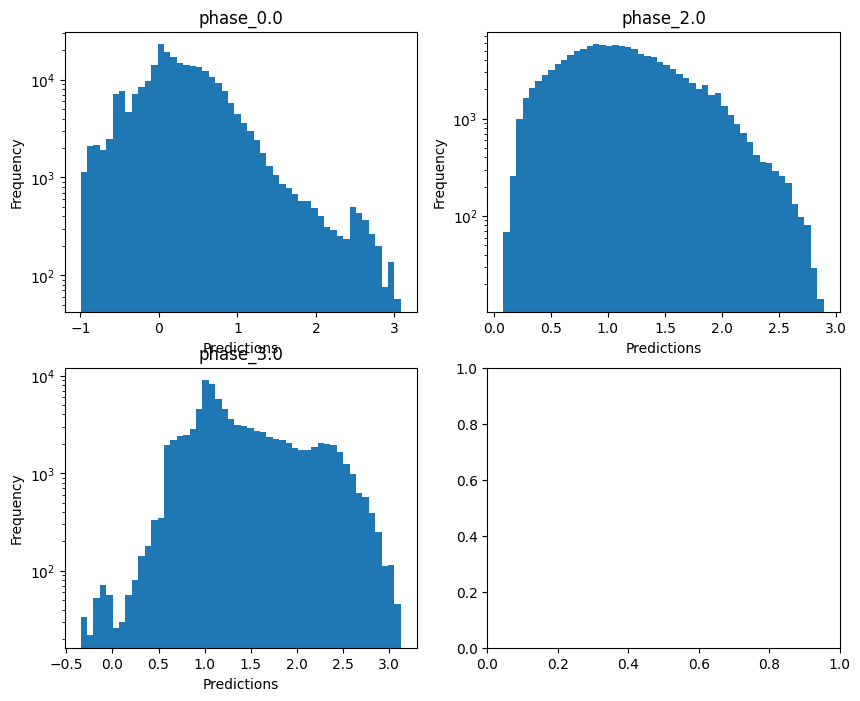

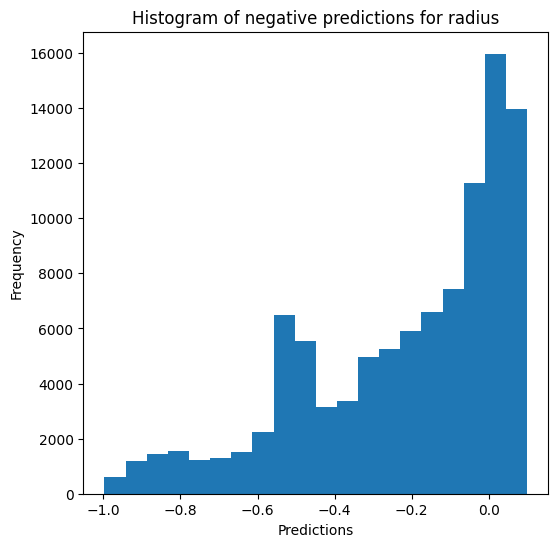

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9932932634026369
  RMSE :  2.1541470574478225
  MAE :  0.3068505970796098
  MedAE :  0.007175082891891282
  CORR :  0.9967472328950062
  MAX_ER :  99.43297165803614
  Percentiles : 
    75th percentile :  0.03787762860451238
    90th percentile :  0.23133969829184484
    95th percentile :  0.7230547575680529
    99th percentile :  7.081171361490293

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9993692632118909
  RMSE :  0.7457669184027538
  MAE :  0.09312048656305022
  MedAE :  0.004696177137613833
  CORR :  0.9996845845047237
  MAX_ER :  37.48661252169403
  Percentiles : 
    75th percentile :  0.018188436350032422
    90th percentile :  0.08060584009835933
    95th 

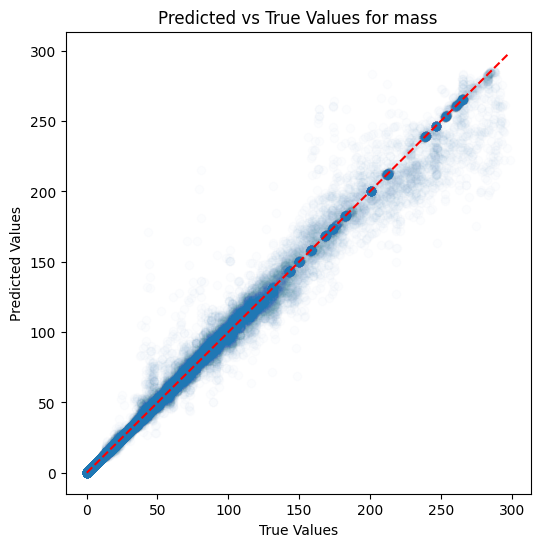

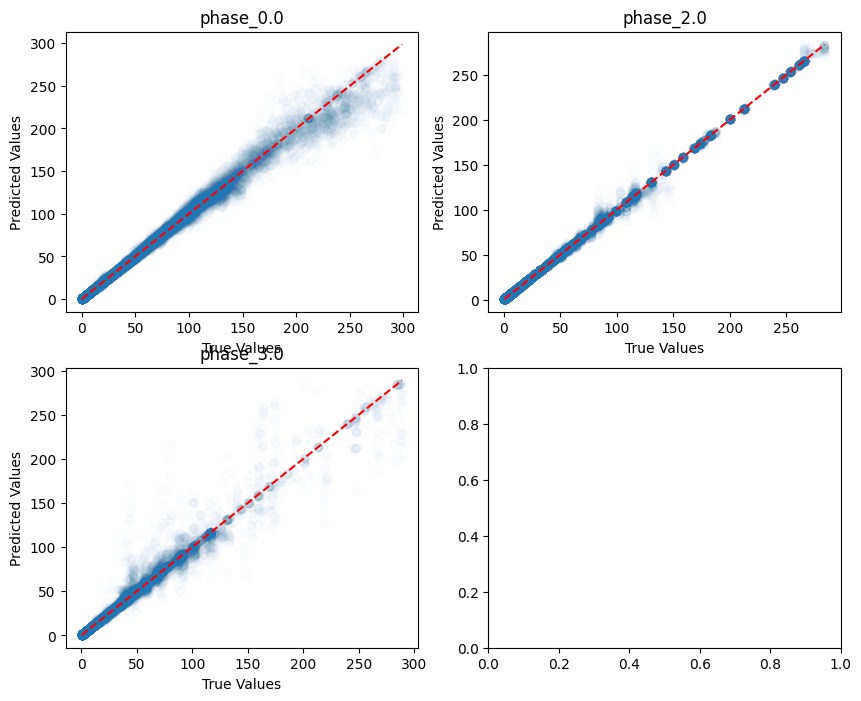

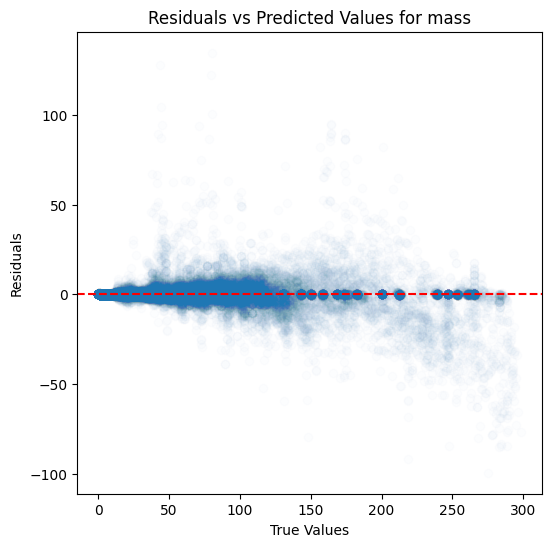

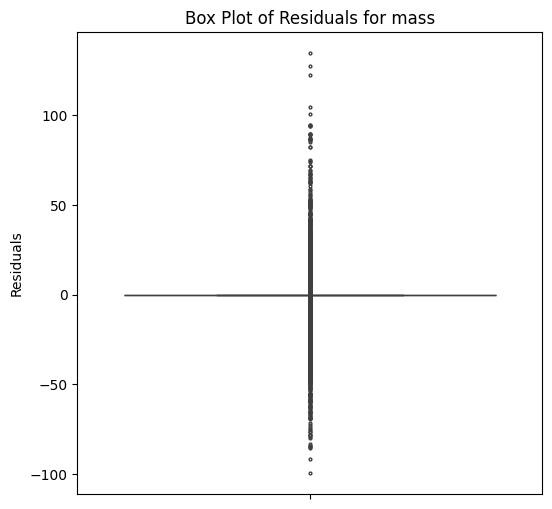

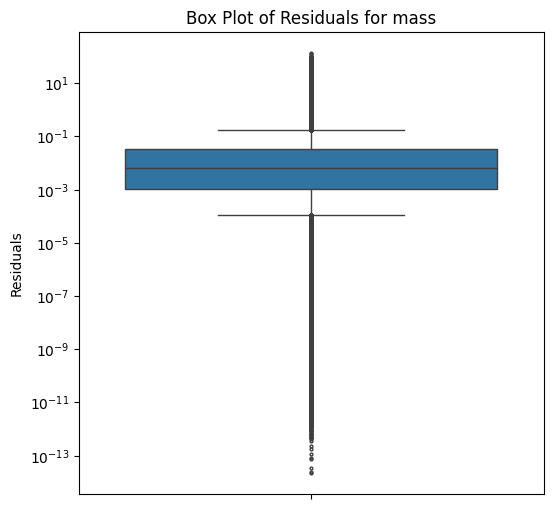

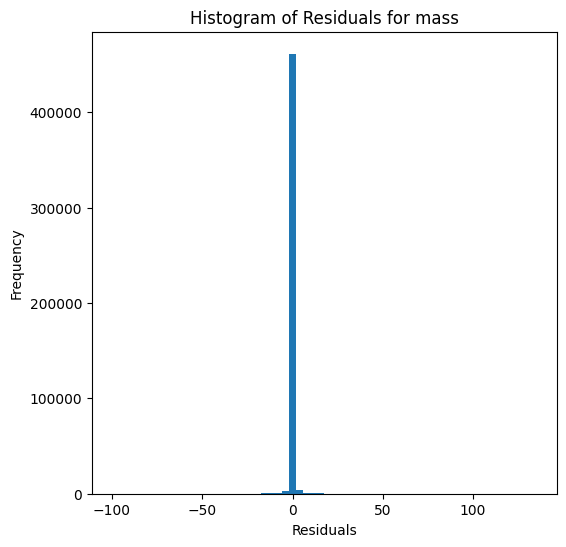

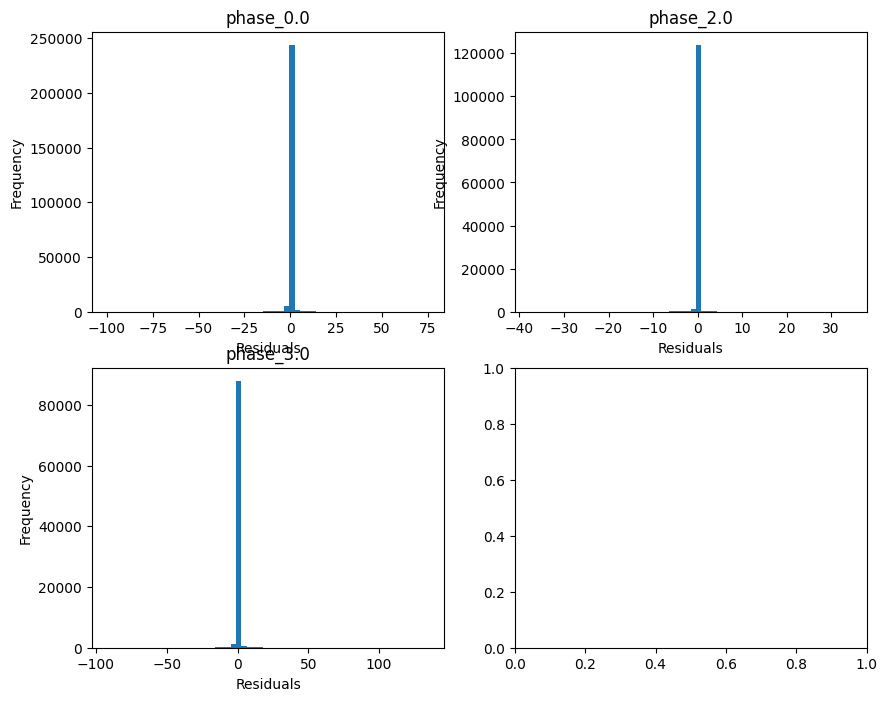

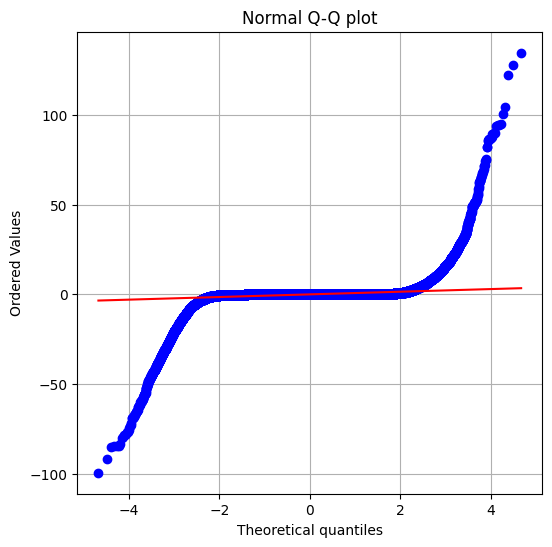

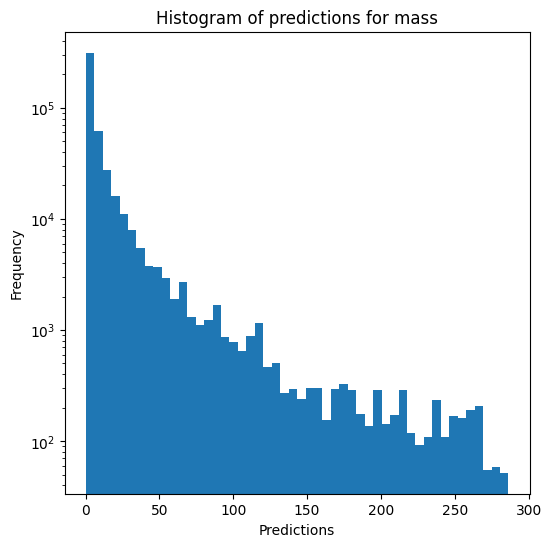

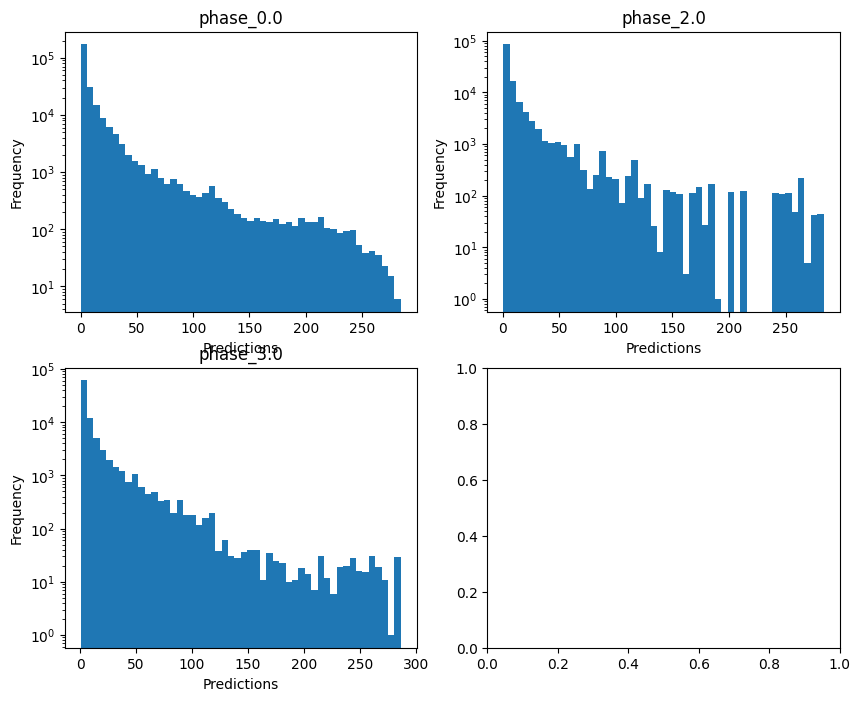


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999061433404434
  RMSE :  0.005525502335681725
  MAE :  0.003448817009169775
  MedAE :  0.002259077600864162
  CORR :  0.9999531781246771
  MAX_ER :  0.11636461602669157
  Percentiles : 
    75th percentile :  0.00429196974427512
    90th percentile :  0.007540683293029021
    95th percentile :  0.010504098505859361
    99th percentile :  0.020541011437810314

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.99989736807755
  RMSE :  0.004970943934803371
  MAE :  0.0035722158927513703
  MedAE :  0.0026634077983719306
  CORR :  0.9999486833289599
  MAX_ER :  0.07723242145030396
  Percentiles : 
    75th percentile :  0.004751664347051376
    90th percentile :  0.007817243557565412
    95th percentile :  0.010110263711981161
    99th percentile :  0.01560689864845947

radius results for 

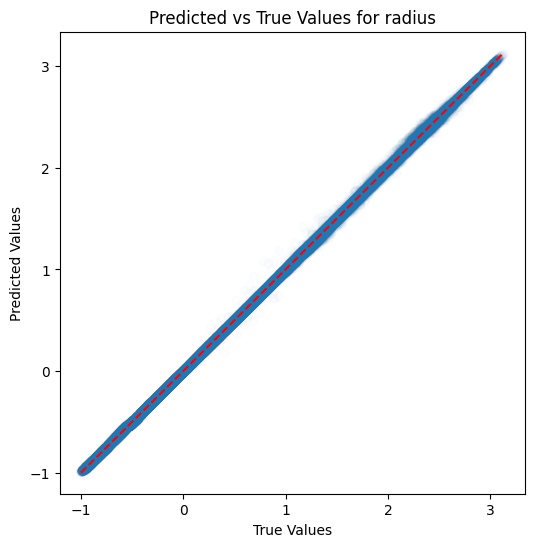

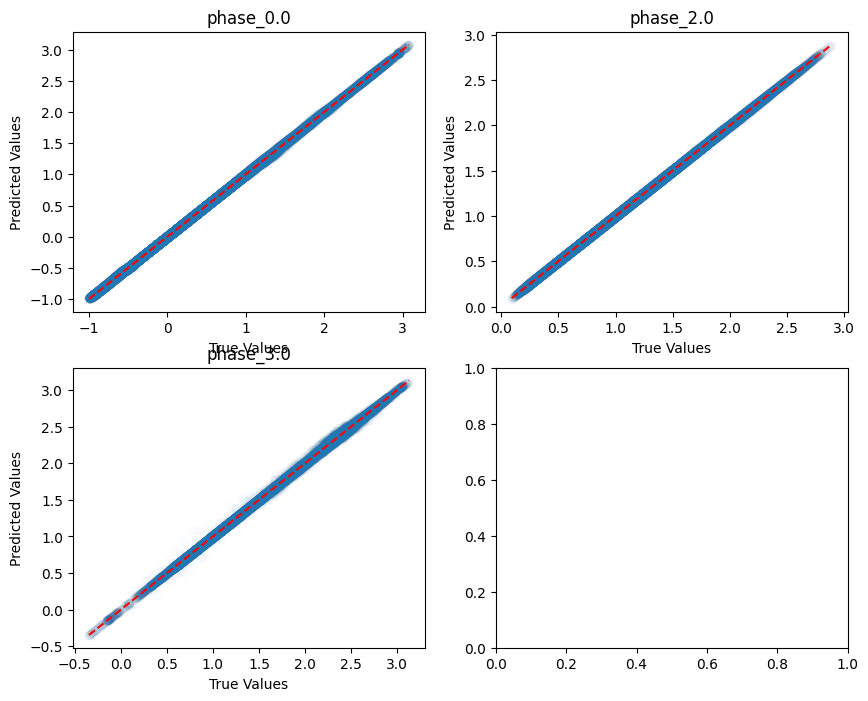

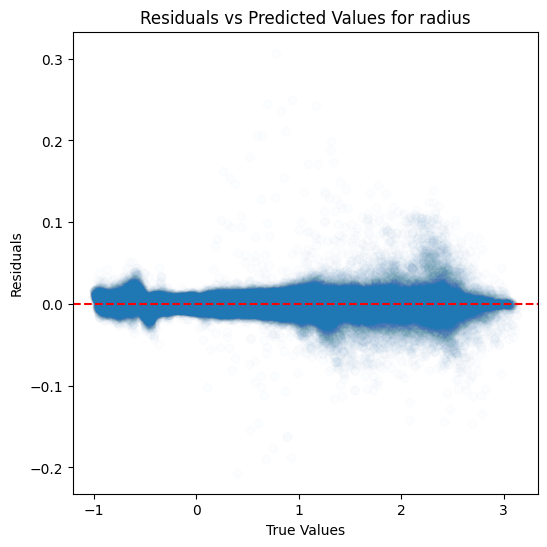

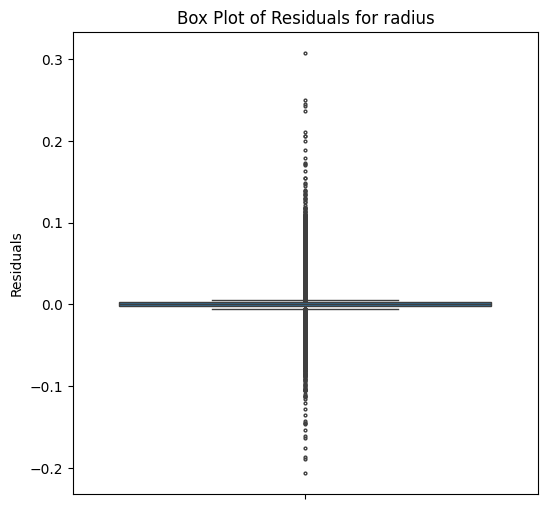

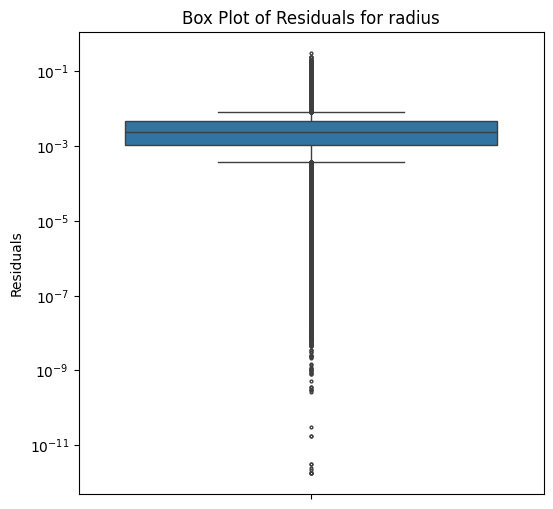

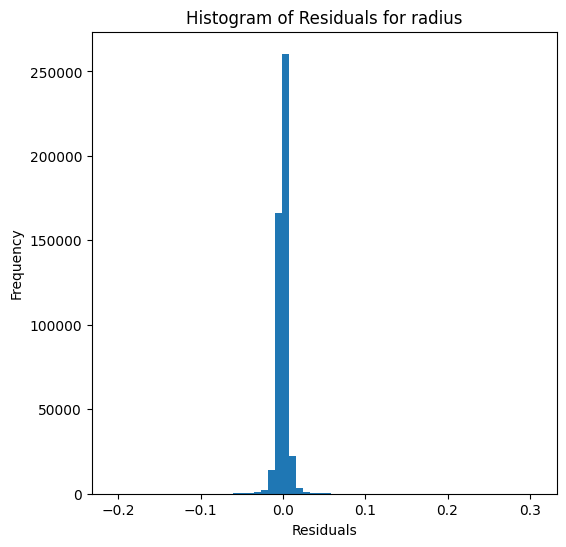

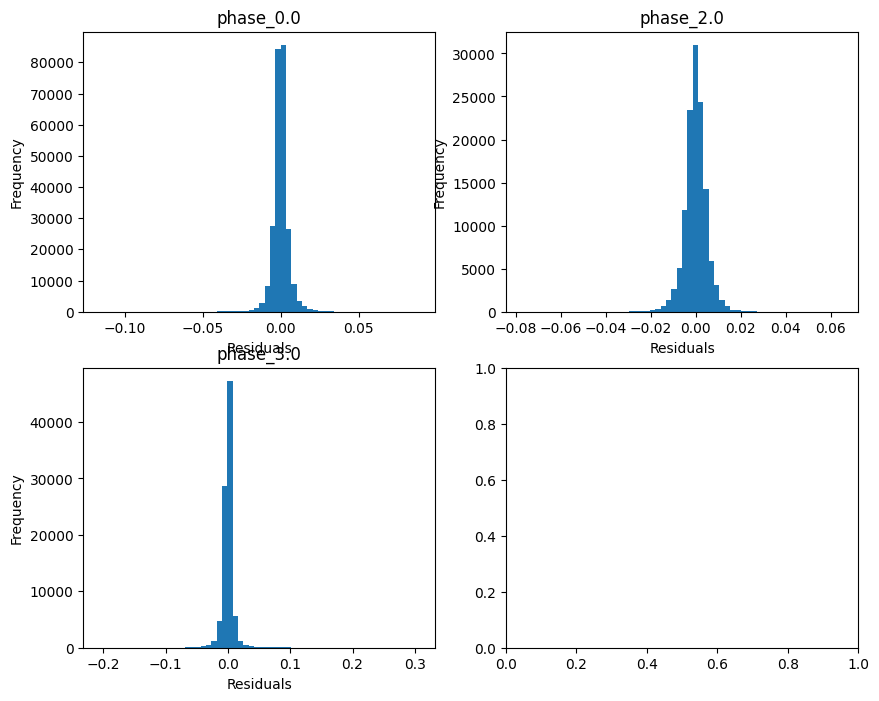

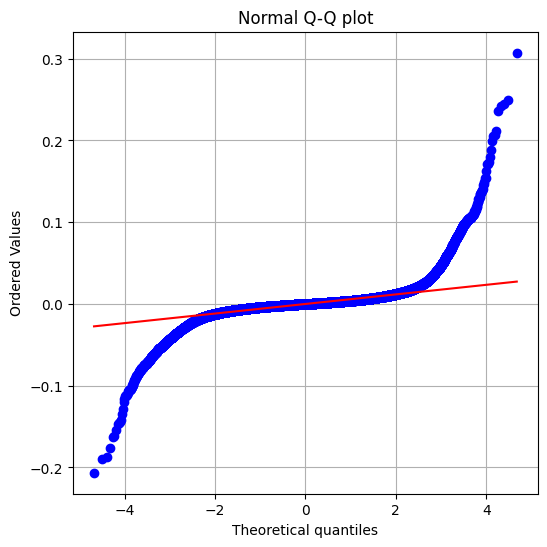

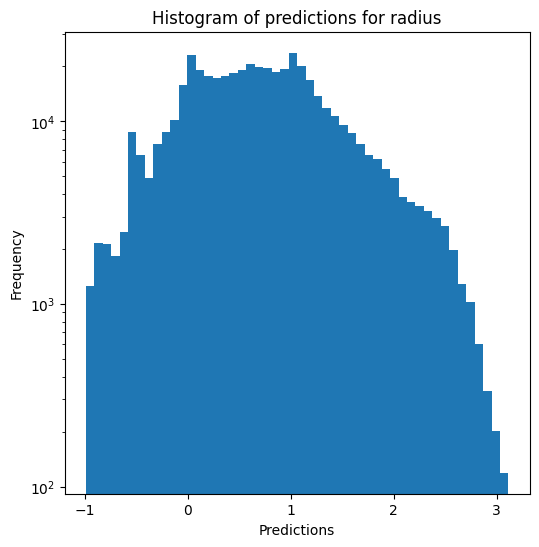

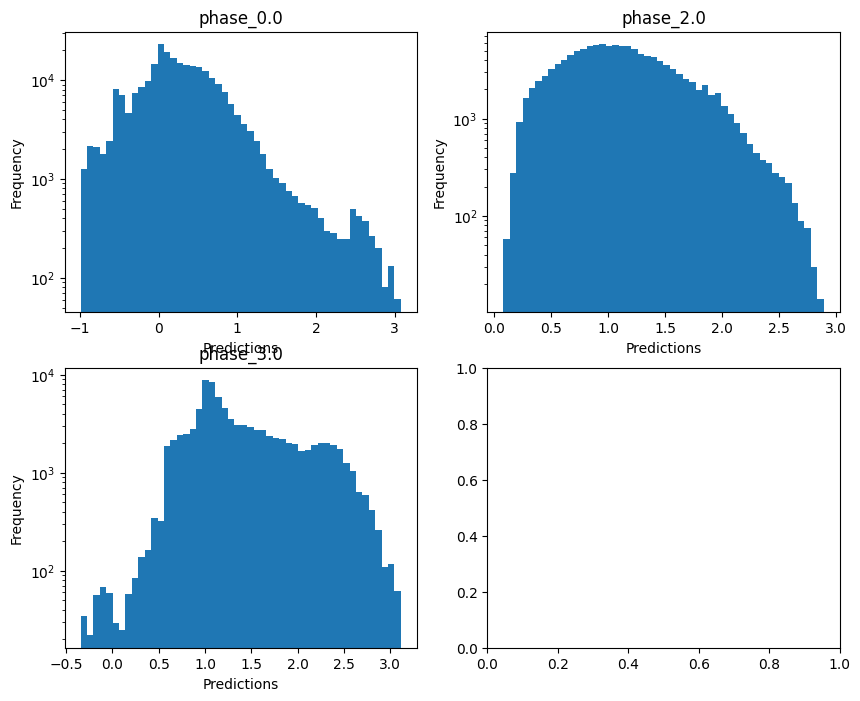

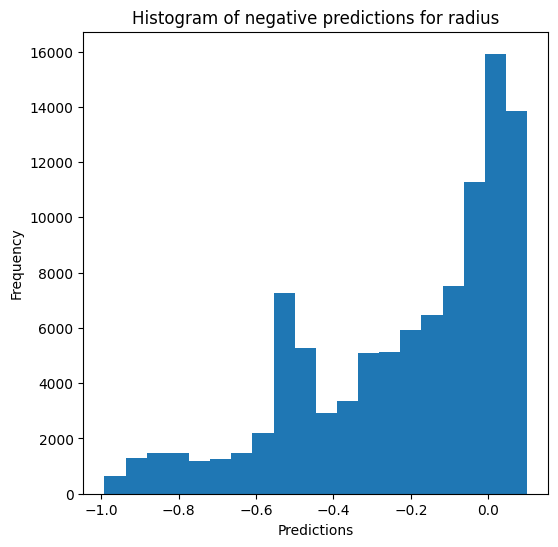

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9973939454997334
  RMSE :  1.3428495500498603
  MAE :  0.1673613209727683
  MedAE :  0.0035543204273937867
  CORR :  0.9986977751621089
  MAX_ER :  82.80692748077405
  Percentiles : 
    75th percentile :  0.016440096069759158
    90th percentile :  0.10840205973140801
    95th percentile :  0.41539588410176537
    99th percentile :  3.594955914769204

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9997472754685565
  RMSE :  0.4720977477922896
  MAE :  0.05923458443771085
  MedAE :  0.004043516517202583
  CORR :  0.9998742090282583
  MAX_ER :  17.873515387756555
  Percentiles : 
    75th percentile :  0.010558037412788046
    90th percentile :  0.02565690801184095
    95th percentile :  0

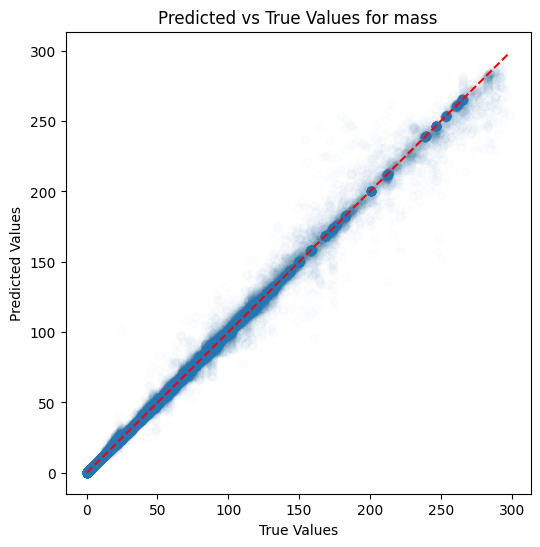

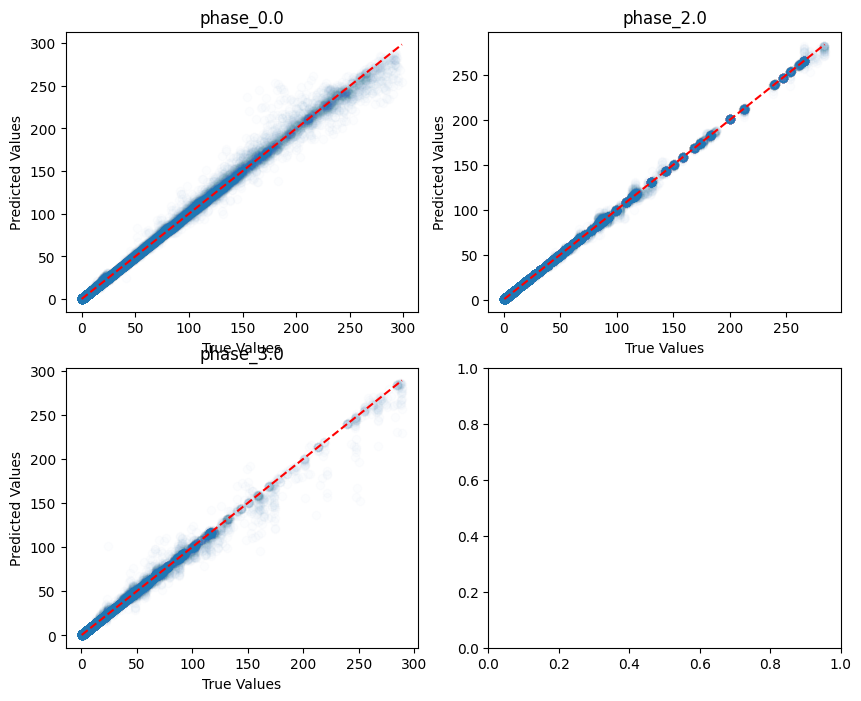

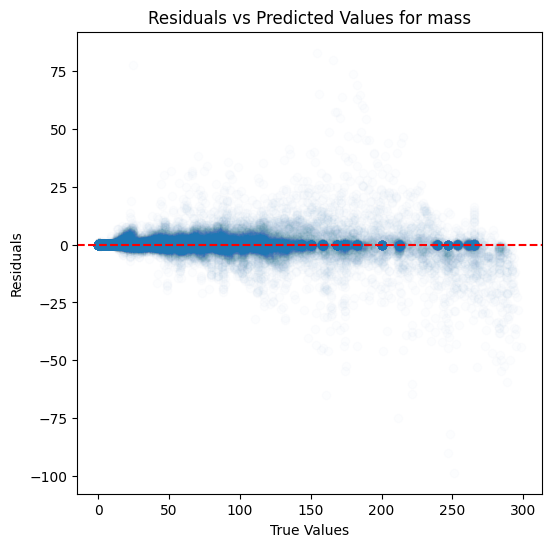

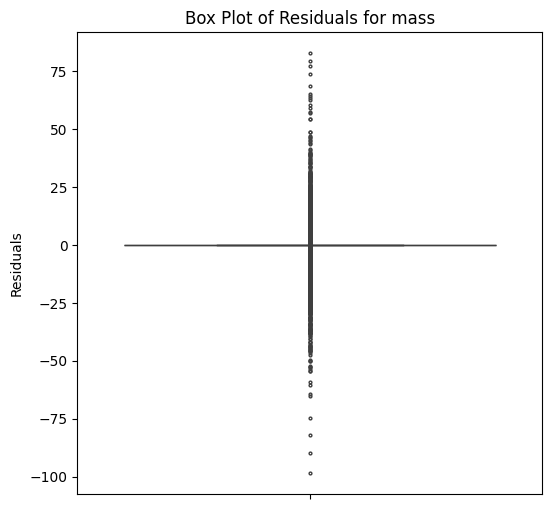

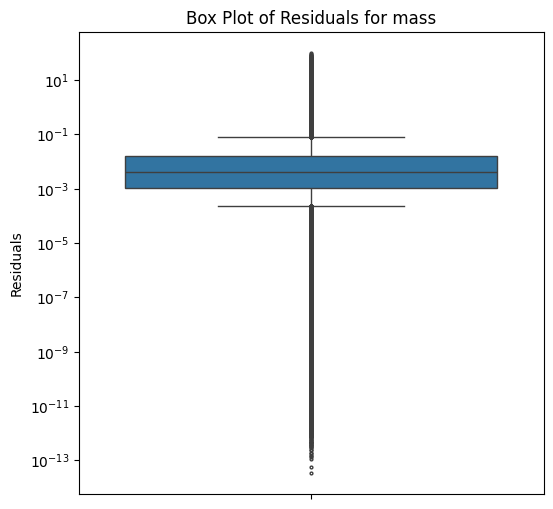

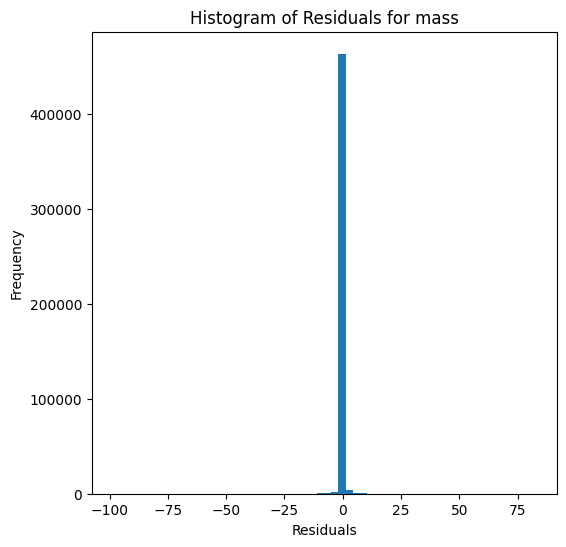

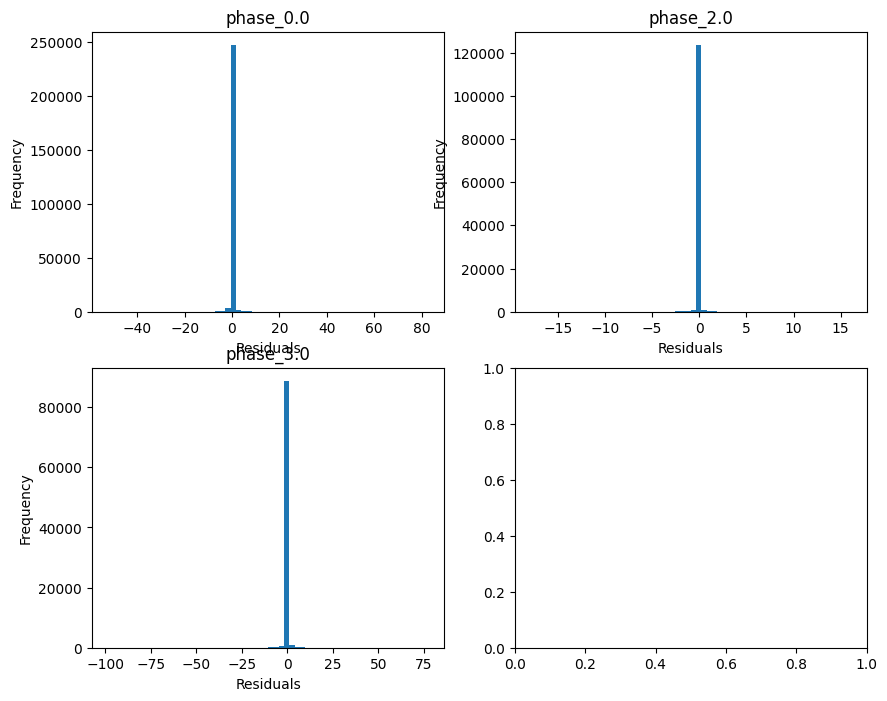

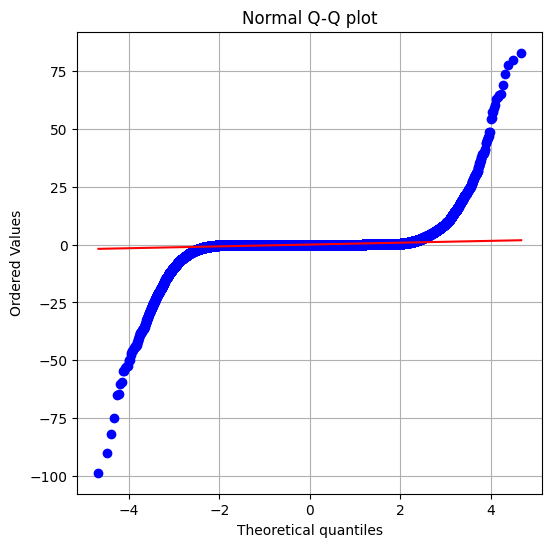

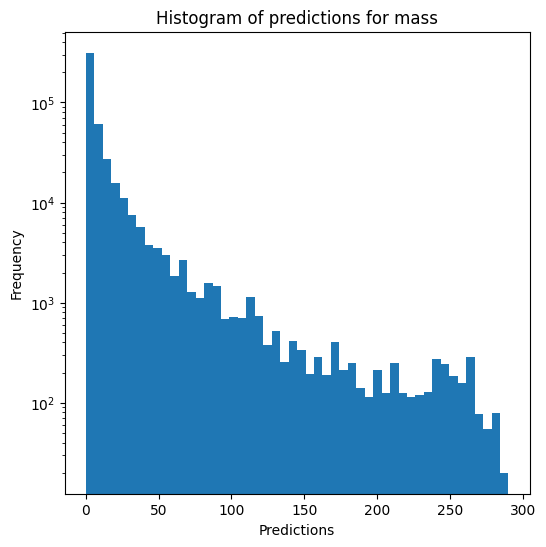

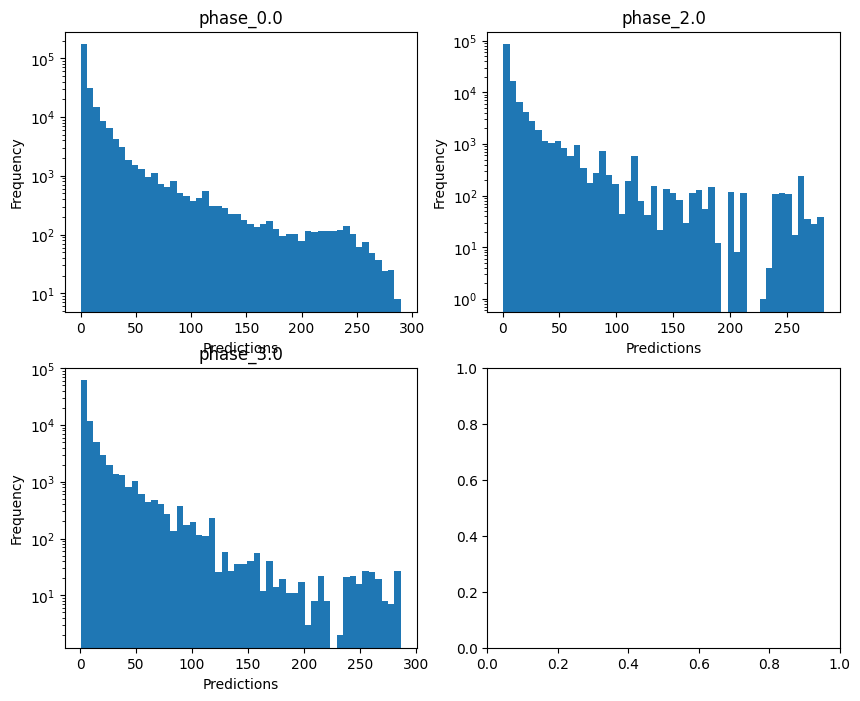

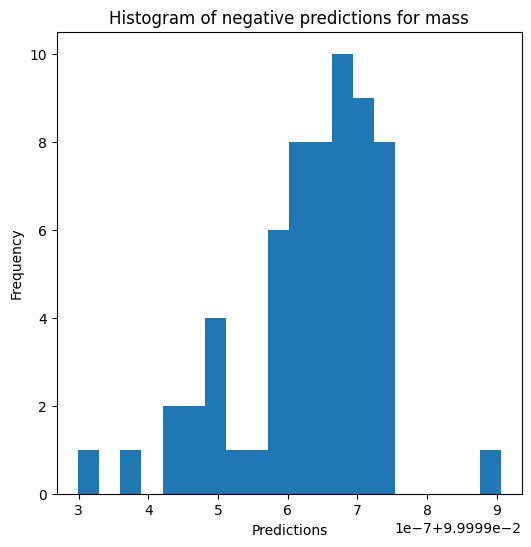


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999463946435571
  RMSE :  0.004175582645135492
  MAE :  0.002083435551966544
  MedAE :  0.0010183367933703363
  CORR :  0.999973241438616
  MAX_ER :  0.3781369684350613
  Percentiles : 
    75th percentile :  0.002326838503233432
    90th percentile :  0.0048503608767527144
    95th percentile :  0.007463379808737207
    99th percentile :  0.016429865543447535

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999325593577166
  RMSE :  0.004058574816749633
  MAE :  0.0026817918314956755
  MedAE :  0.001759844340900374
  CORR :  0.9999669250325012
  MAX_ER :  0.10271672775299967
  Percentiles : 
    75th percentile :  0.003589403212442277
    90th percentile :  0.006147100903839098
    95th percentile :  0.008205801951663316
    99th percentile :  0.014209362794780103

radius results f

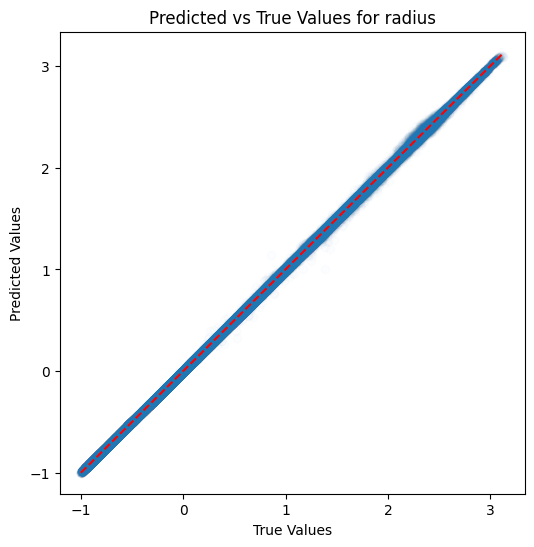

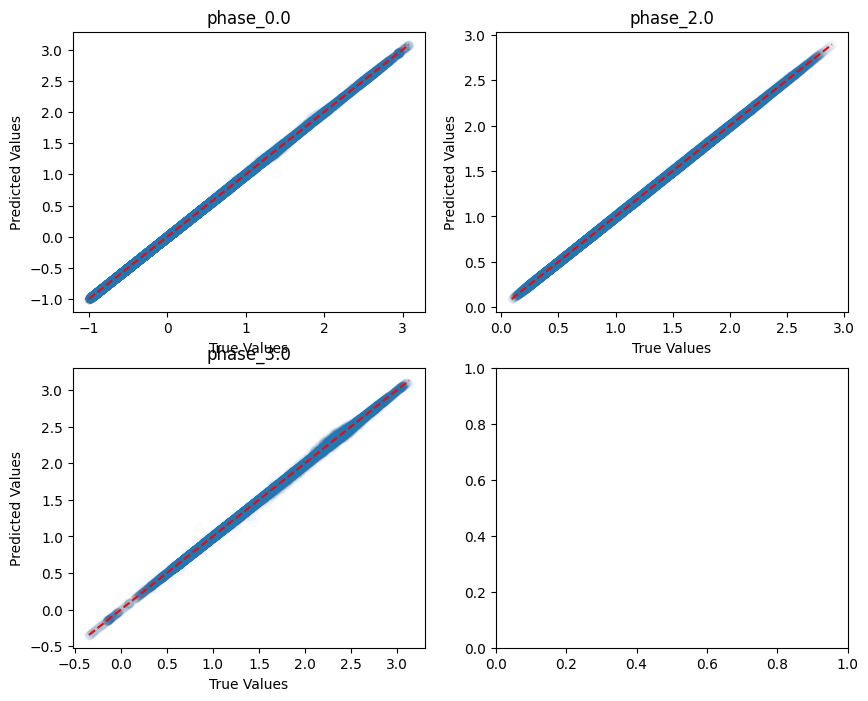

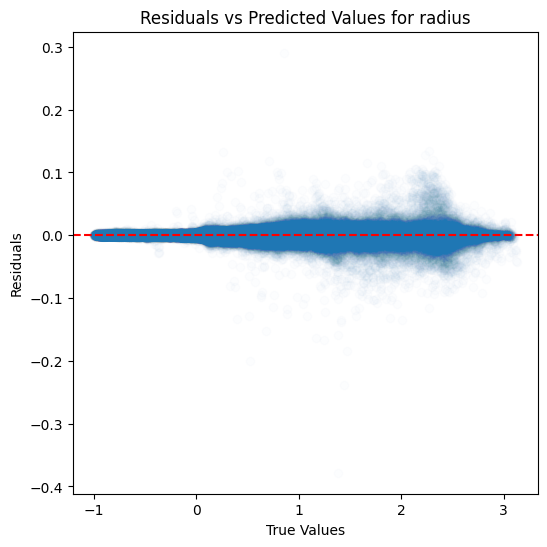

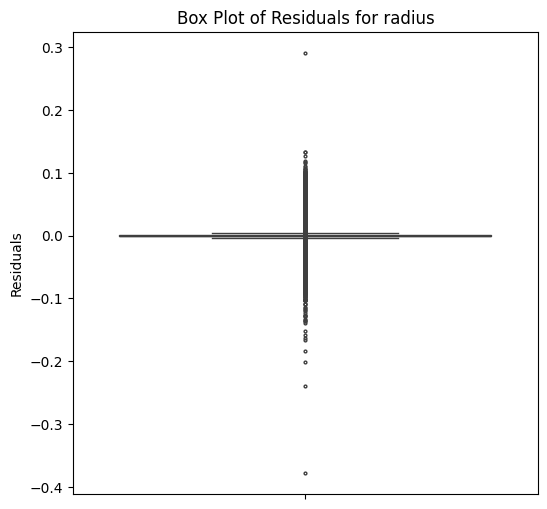

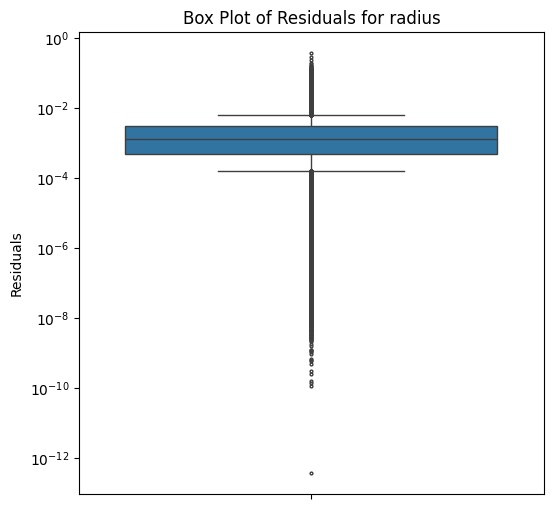

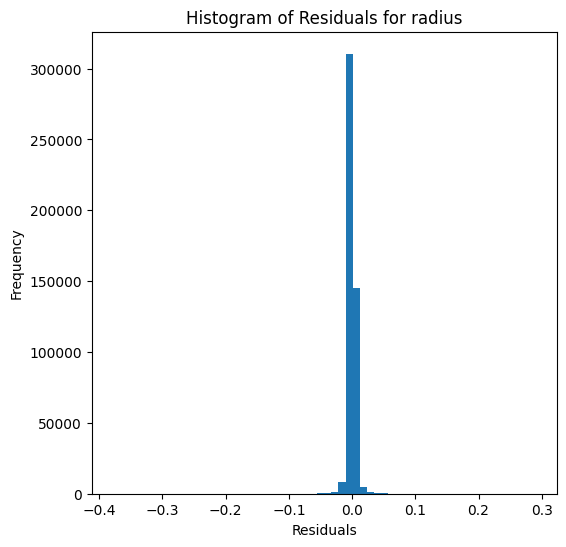

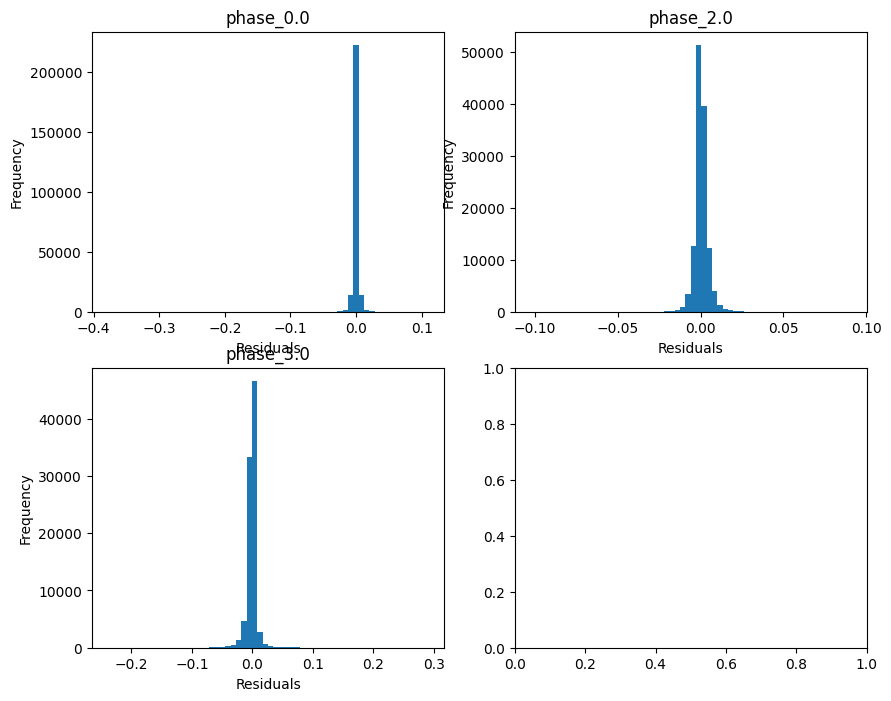

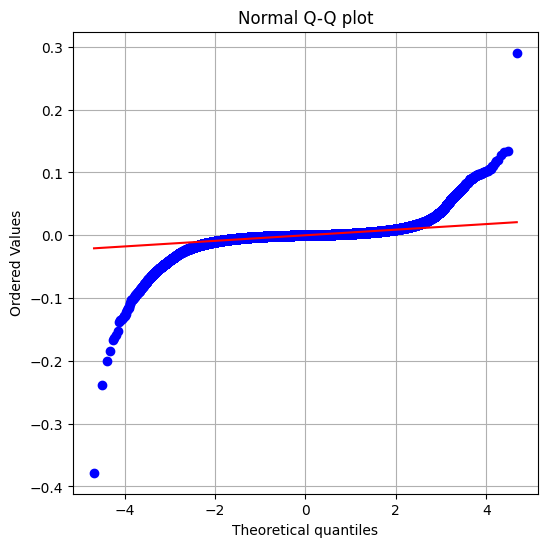

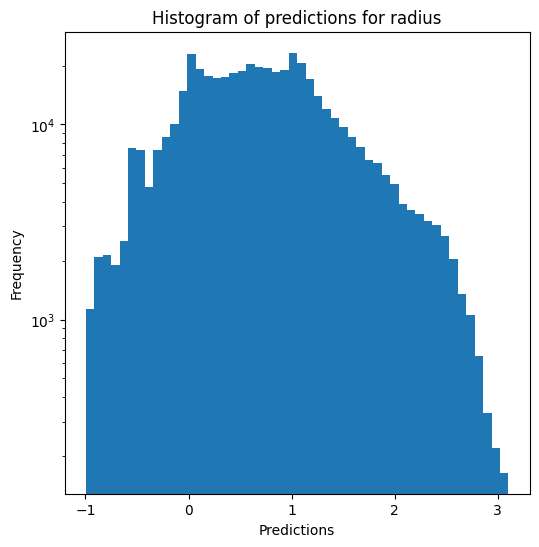

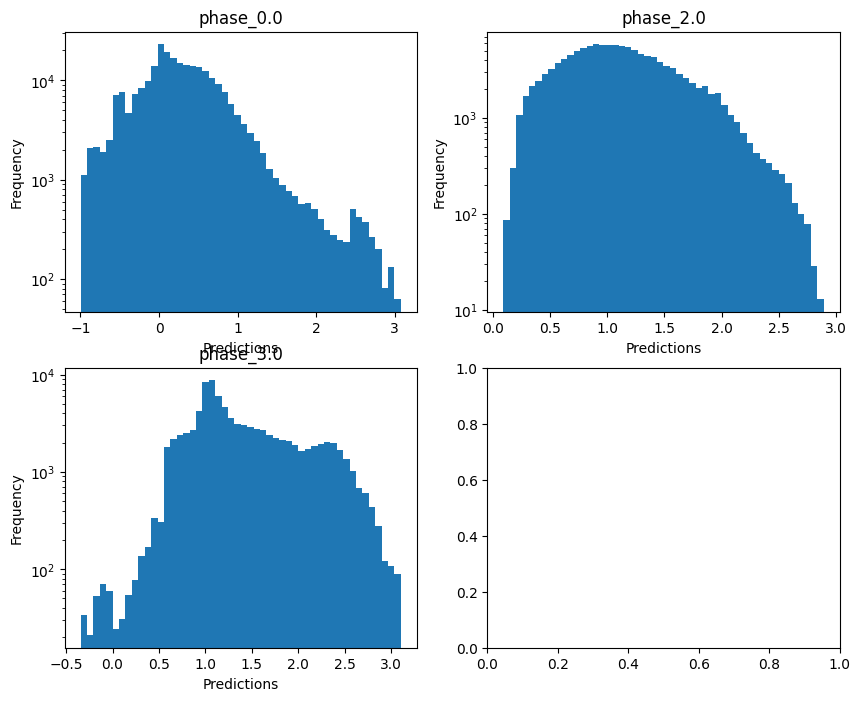

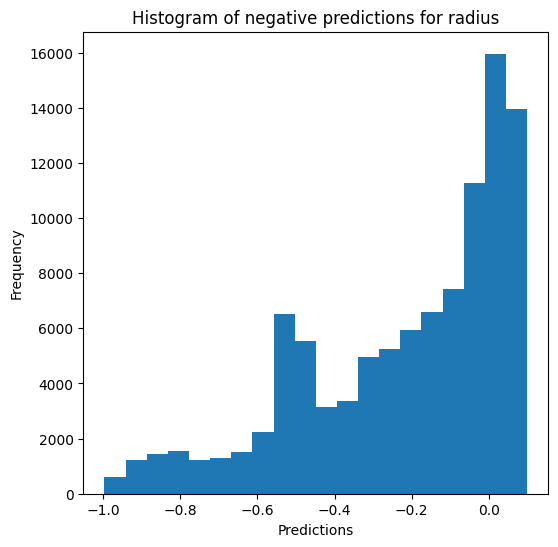

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9911465172719105
  RMSE :  2.474734929971861
  MAE :  0.6760857378348515
  MedAE :  0.12725408958111295
  CORR :  0.9955836103839013
  MAX_ER :  75.48444222351264
  Percentiles : 
    75th percentile :  0.3888267011870792
    90th percentile :  1.2939956923690885
    95th percentile :  2.7054209455457685
    99th percentile :  10.85500055744083

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9988551789361841
  RMSE :  1.0048947305163691
  MAE :  0.29626269766344004
  MedAE :  0.0708645120764082
  CORR :  0.999462981882696
  MAX_ER :  41.74161390163965
  Percentiles : 
    75th percentile :  0.15793158073034386
    90th percentile :  0.5403867168558322
    95th percentile :  1.343612877395

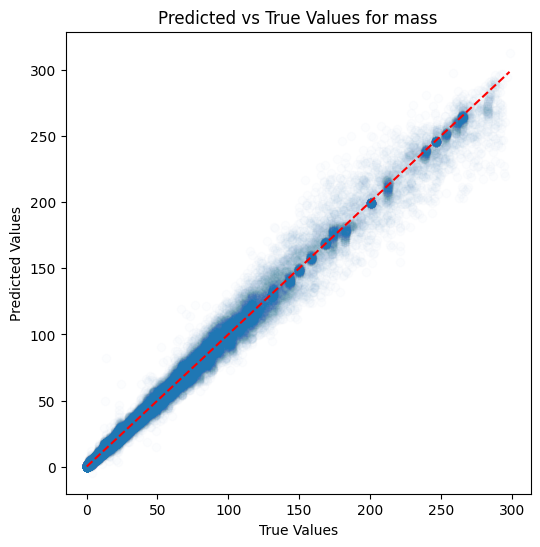

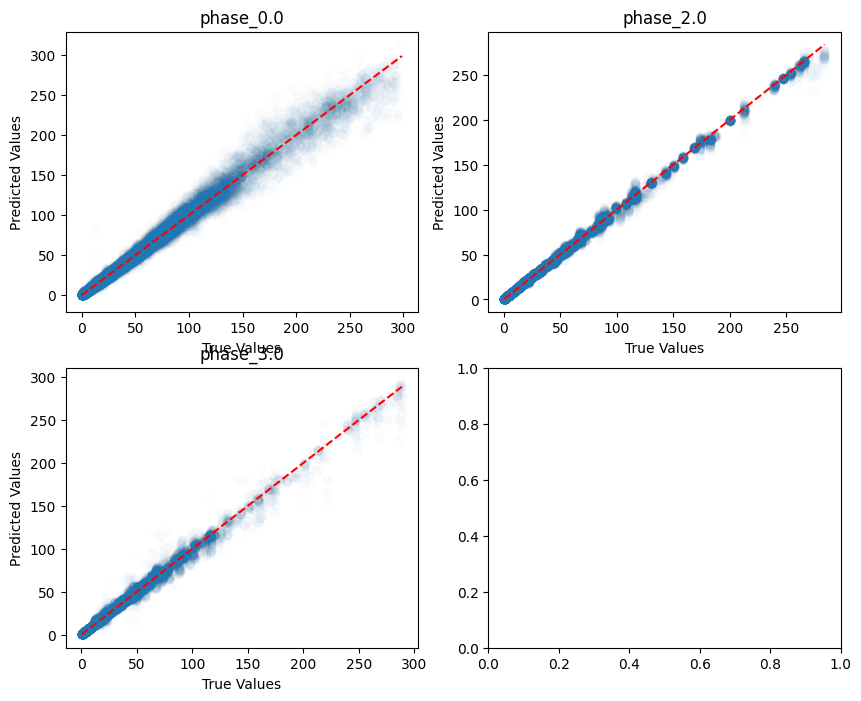

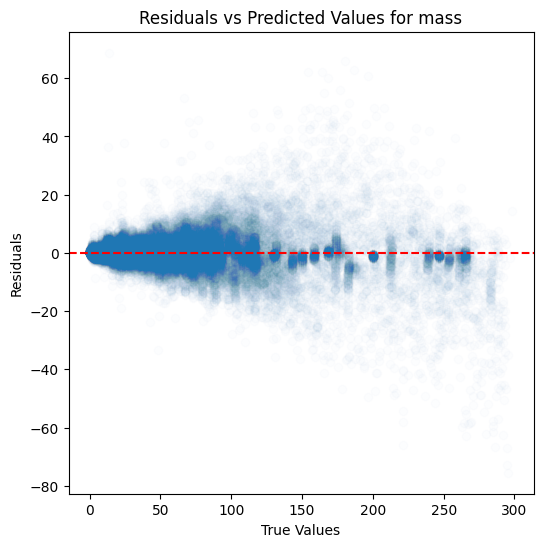

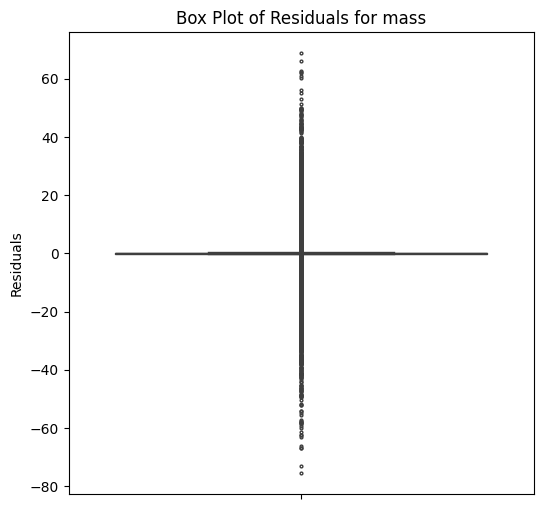

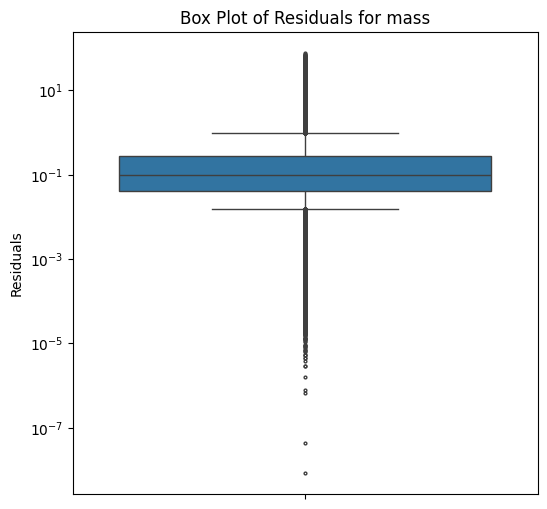

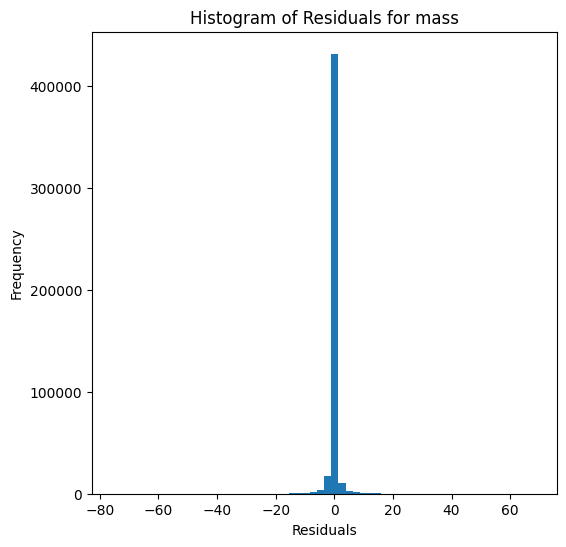

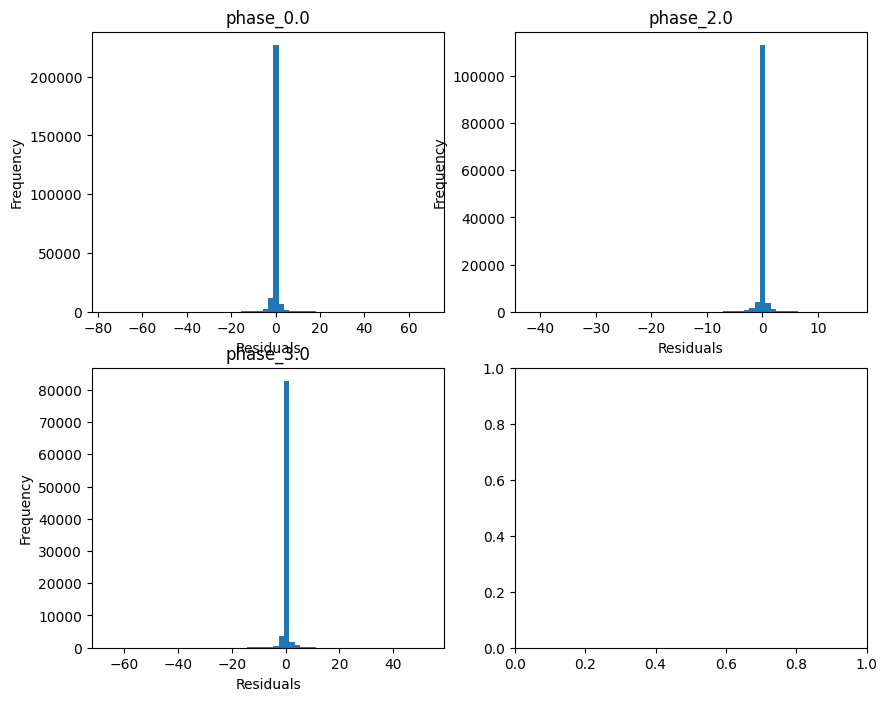

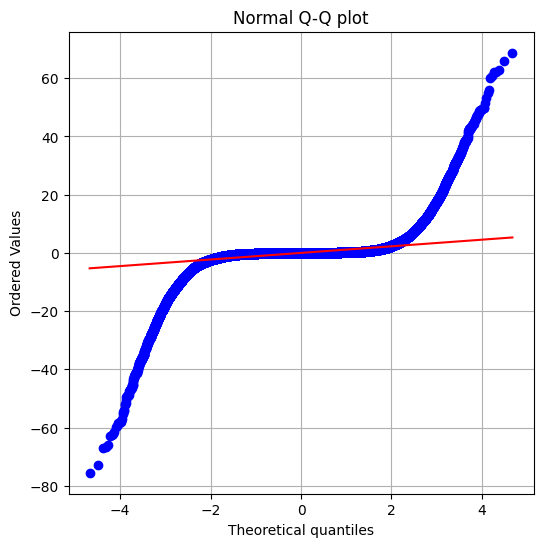

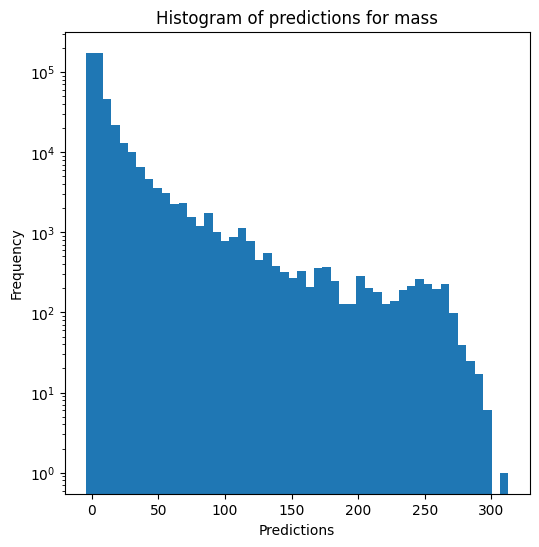

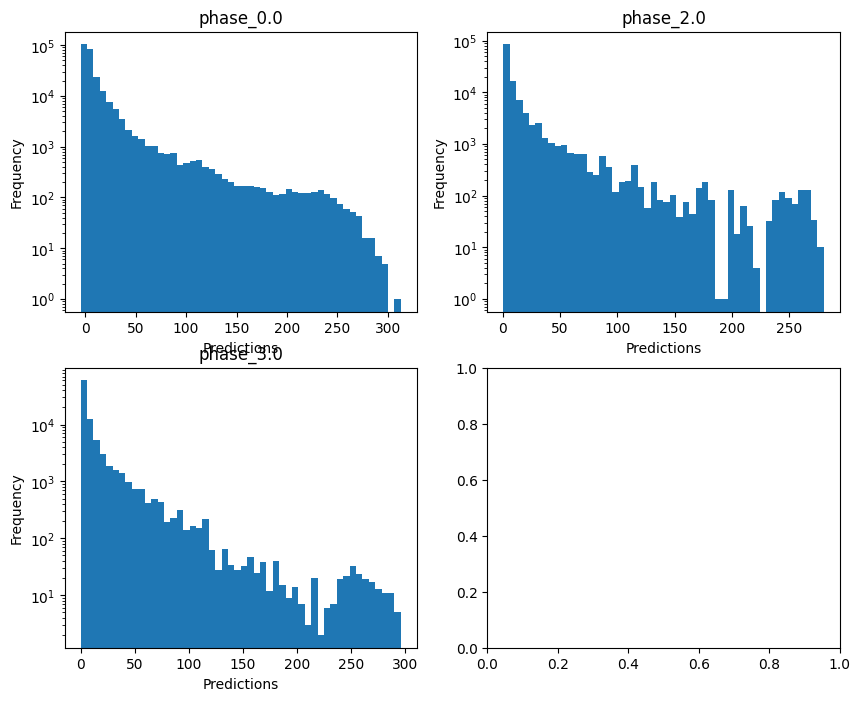

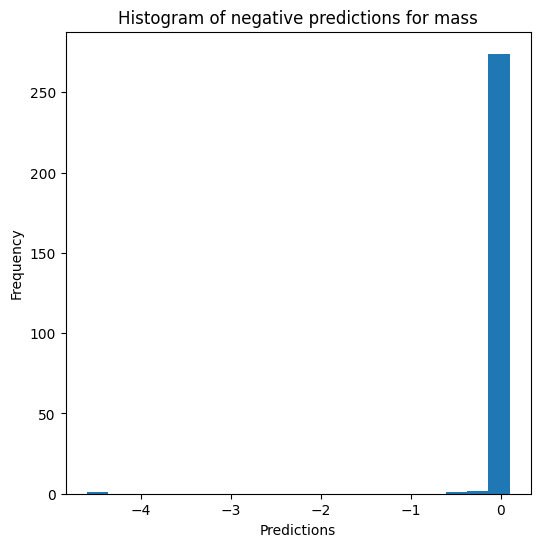


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994435589406726
  RMSE :  0.013452728514697558
  MAE :  0.009896164692894123
  MedAE :  0.0074776569324245395
  CORR :  0.9997217737068496
  MAX_ER :  0.12312026218047523
  Percentiles : 
    75th percentile :  0.013554878712852797
    90th percentile :  0.021451361532727076
    95th percentile :  0.027451809133512882
    99th percentile :  0.04200738197120429

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9992114671557197
  RMSE :  0.013792953252647634
  MAE :  0.010757373363003753
  MedAE :  0.00880739136378561
  CORR :  0.9996062681034856
  MAX_ER :  0.08440279311583998
  Percentiles : 
    75th percentile :  0.015304970600621748
    90th percentile :  0.02252963696603727
    95th percentile :  0.027464078646467625
    99th percentile :  0.03824591763785104

radius results for t

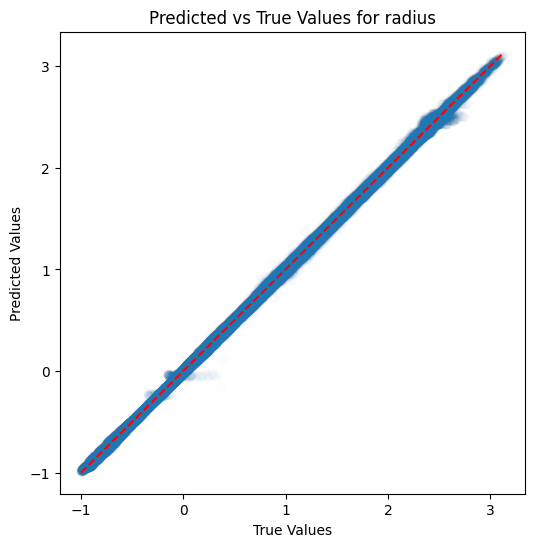

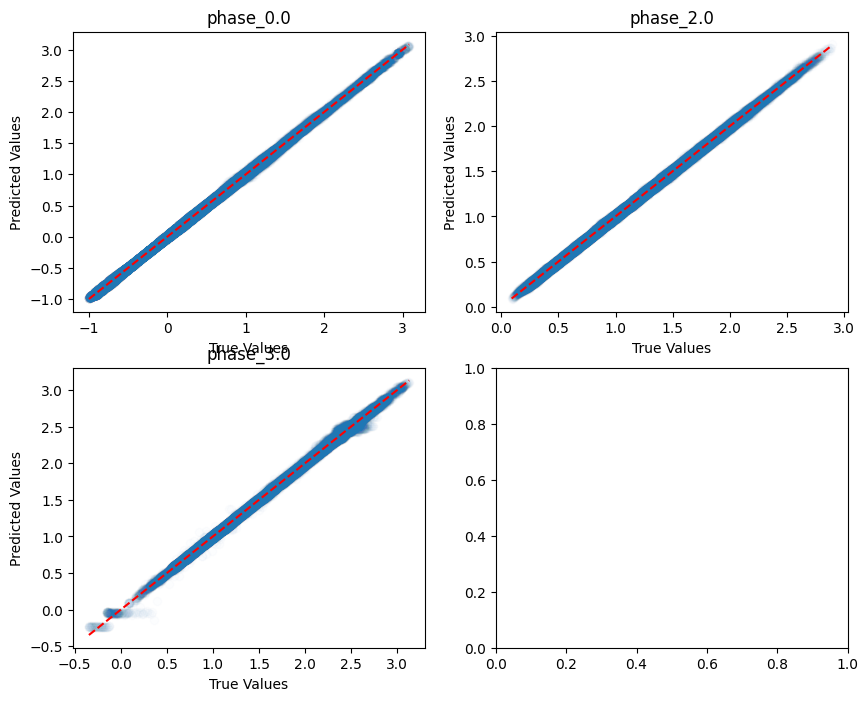

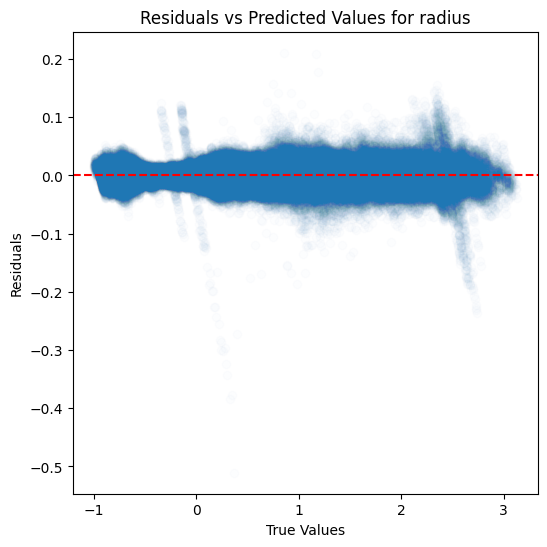

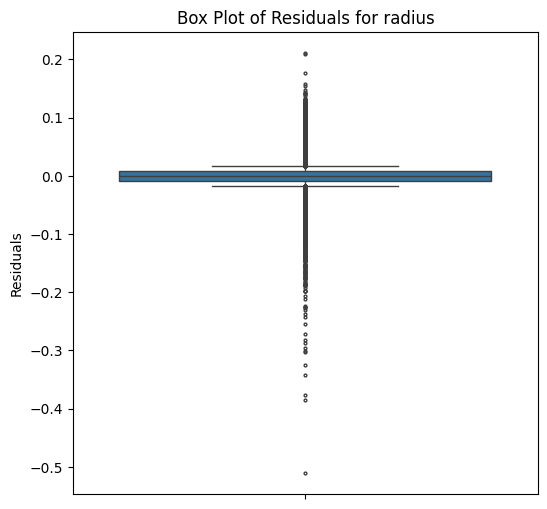

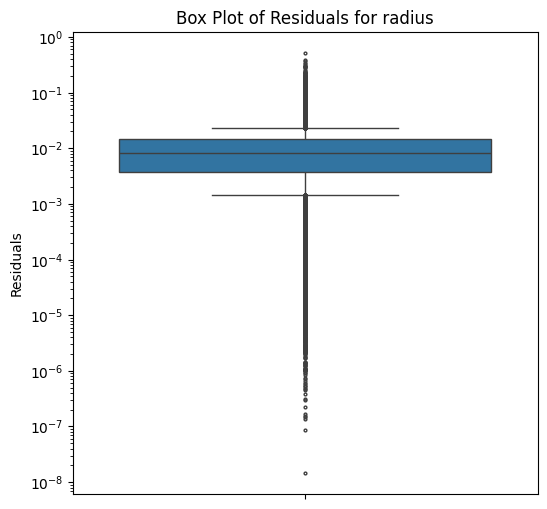

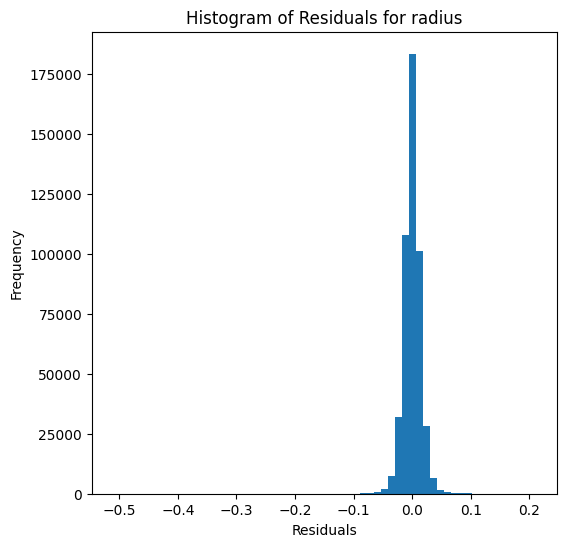

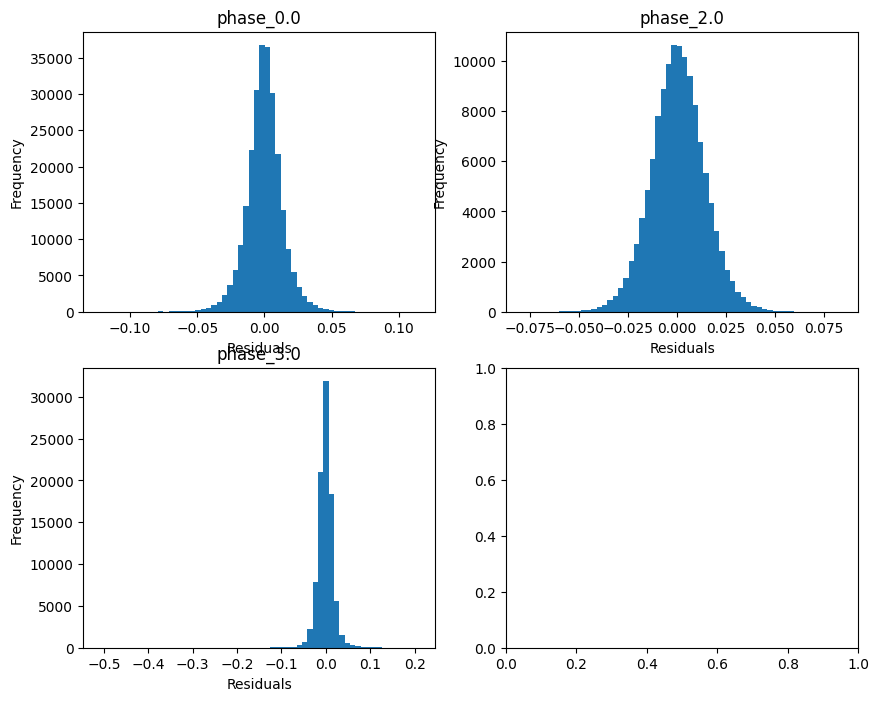

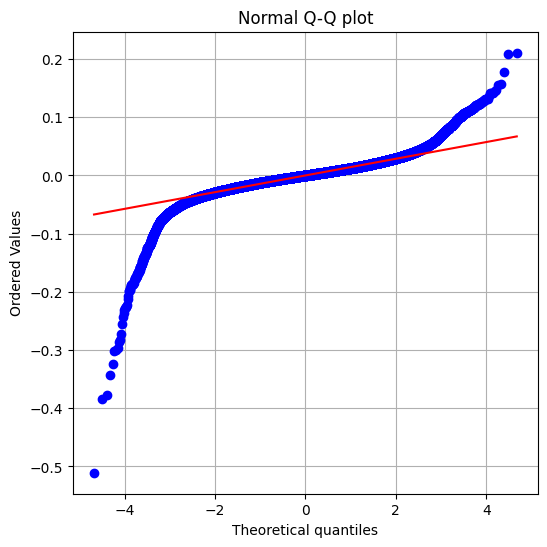

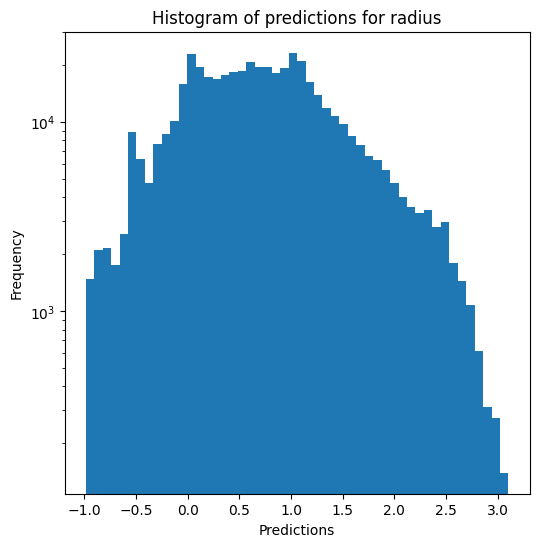

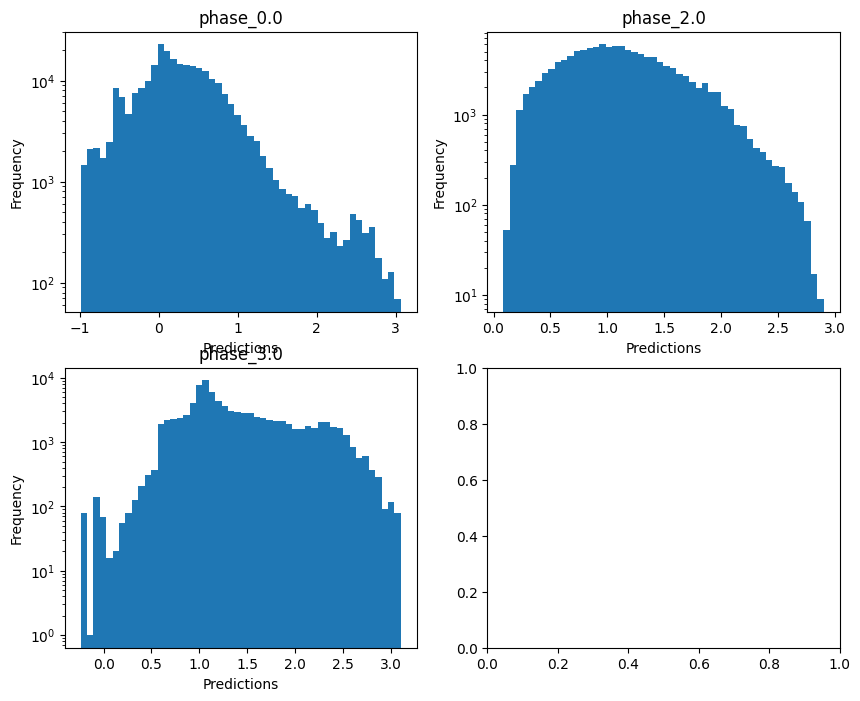

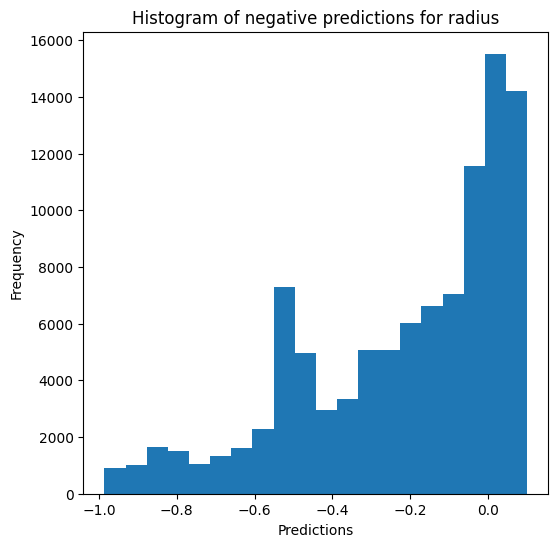

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.8168985639463128
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.8769802680567866
3 

...

0.9506689756909807
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7240380870376945
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9317657005461035

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9928618261439448
  RMSE :  2.2364438251964383
  MAE :  0.6520304755540756
  MedAE :  0.15301757440187244
  CORR :  0.996656567169858
  MAX_ER :  60.58598892961325
  Percentiles : 
    75th percentile :  0.3192414102771285
    90th percentile :  1.2001970871599208
    95th percentile :  3.06699536947506
    99th percentile :  9.040742528994887

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9960907814097686
  RMSE :  1.8578041598757178
  MAE :  0.5531098240835782
  MedAE :  0.14407505579261404
  CORR :  0.998043640605636
  MAX_ER :  37.531436729345856
  Percentiles : 
    75th percentile :  0.3108192692511317
    90th percentile :  0.8203402959840042
    95th percentile :  2.5131428067413877
    99th percentile :  9.183034650540122

mass result

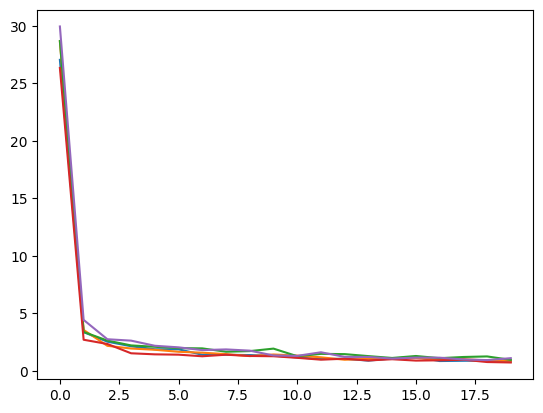

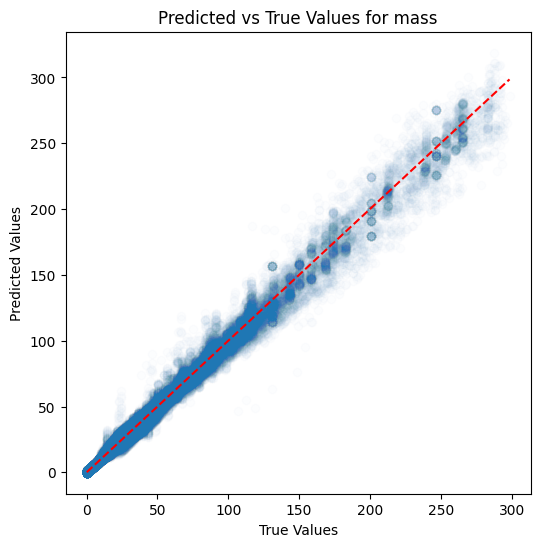

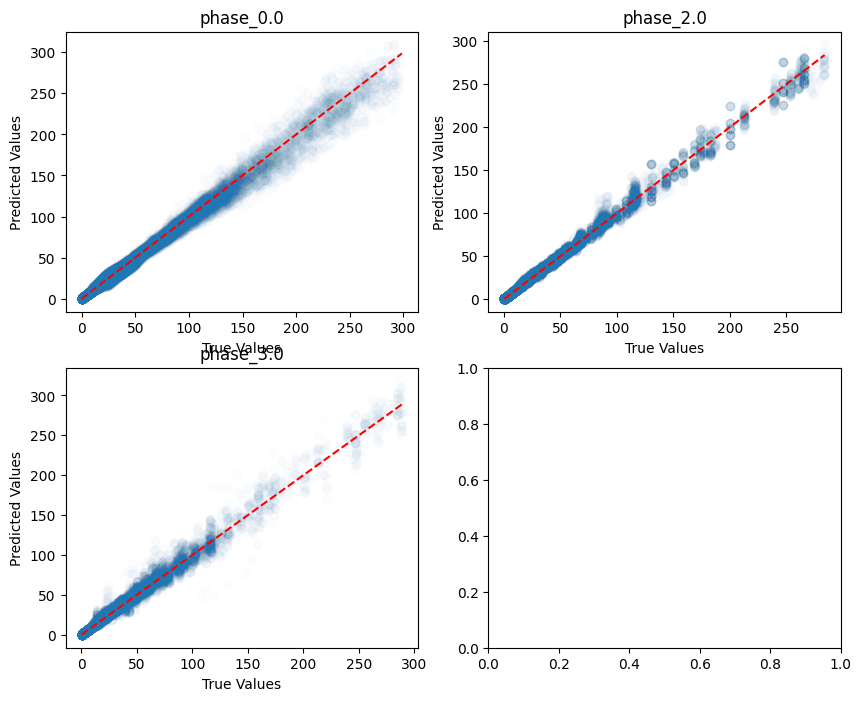

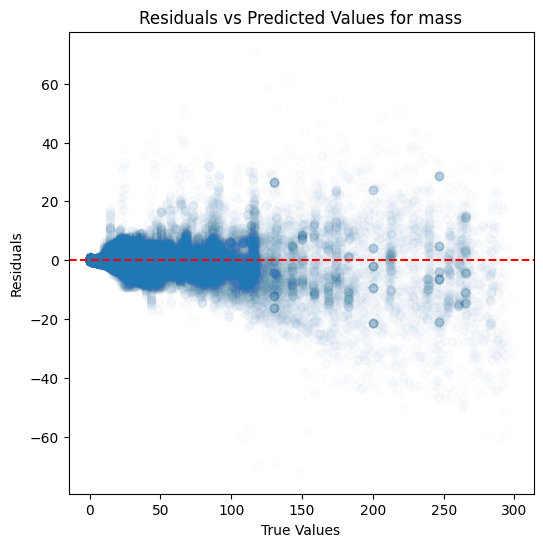

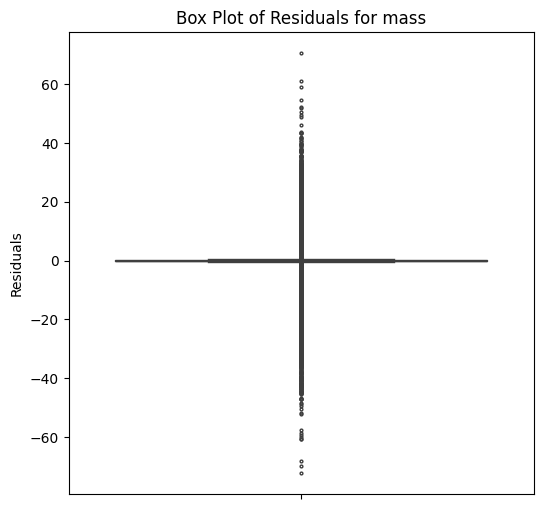

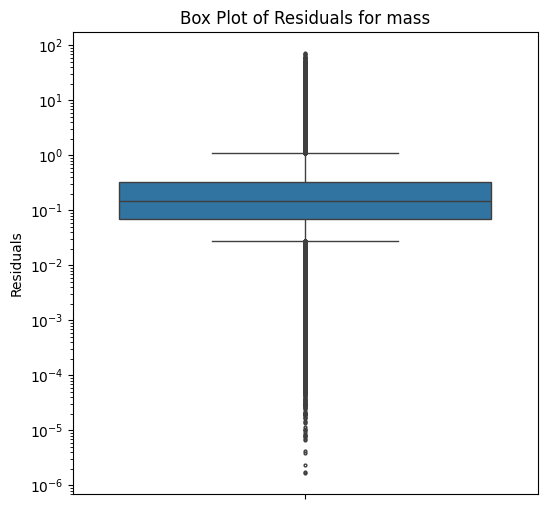

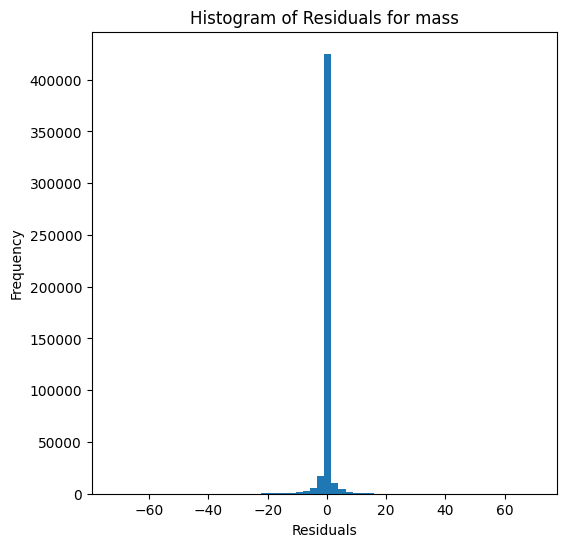

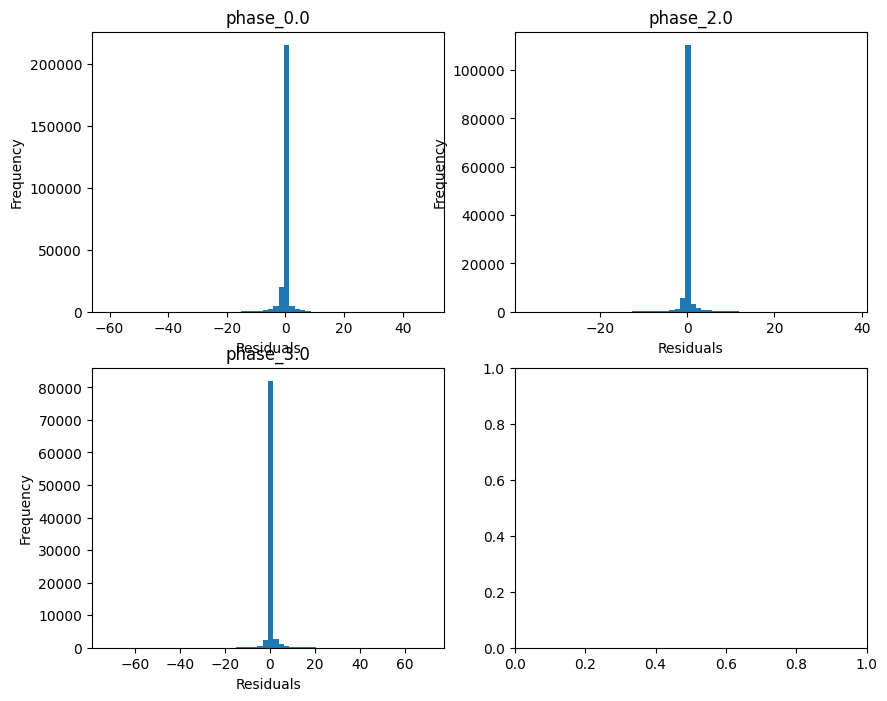

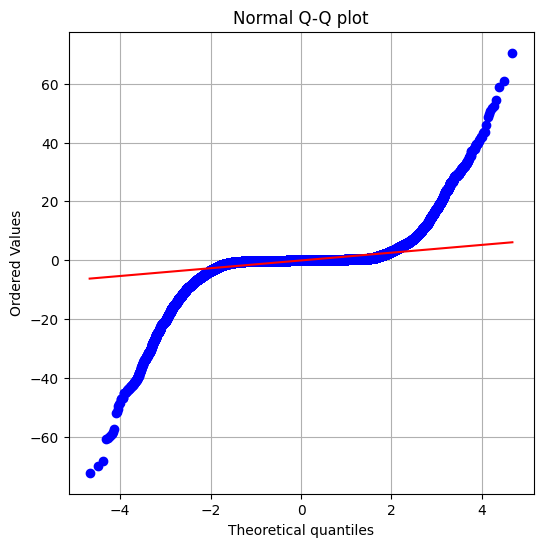

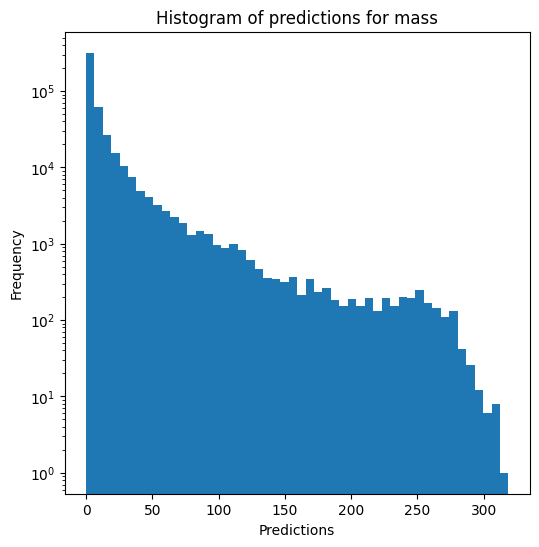

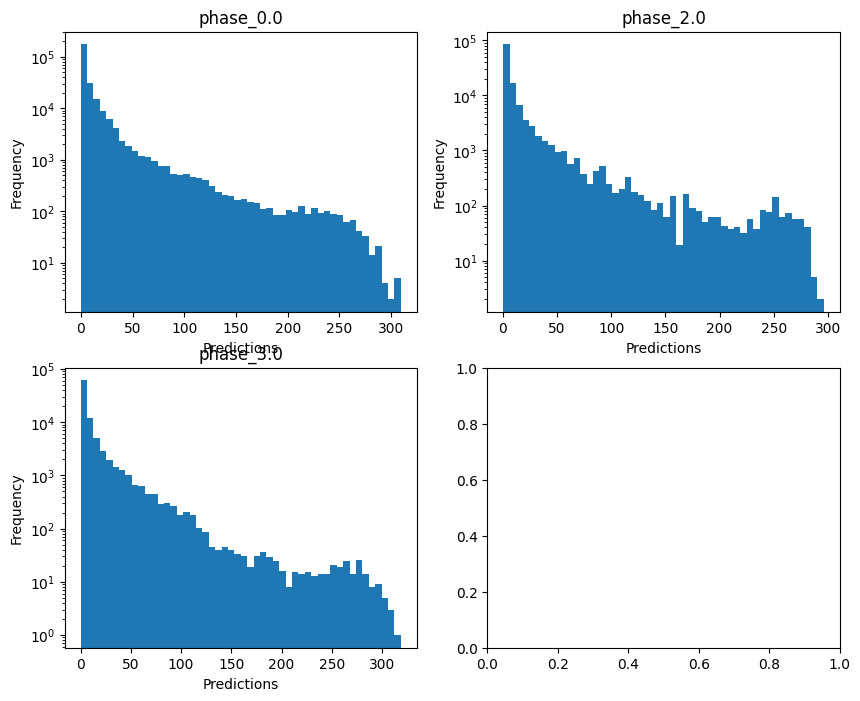

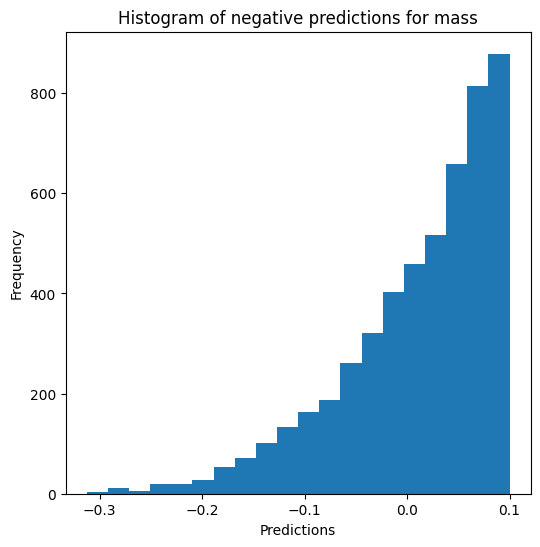


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9880178458443394
  RMSE :  0.06270246678822088
  MAE :  0.04631283728530714
  MedAE :  0.035797730272217526
  CORR :  0.9940987020643219
  MAX_ER :  0.6101342961548404
  Percentiles : 
    75th percentile :  0.06350764273088894
    90th percentile :  0.09765760276904256
    95th percentile :  0.1236766369281356
    99th percentile :  0.20219874639764226

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9884643866996614
  RMSE :  0.052744350090075706
  MAE :  0.039439707374159194
  MedAE :  0.03221530326835409
  CORR :  0.9942391838997061
  MAX_ER :  0.5132053396230785
  Percentiles : 
    75th percentile :  0.054391112600639335
    90th percentile :  0.08024366249392734
    95th percentile :  0.09843511069826817
    99th percentile :  0.14700681702294977

radius results for the phase c

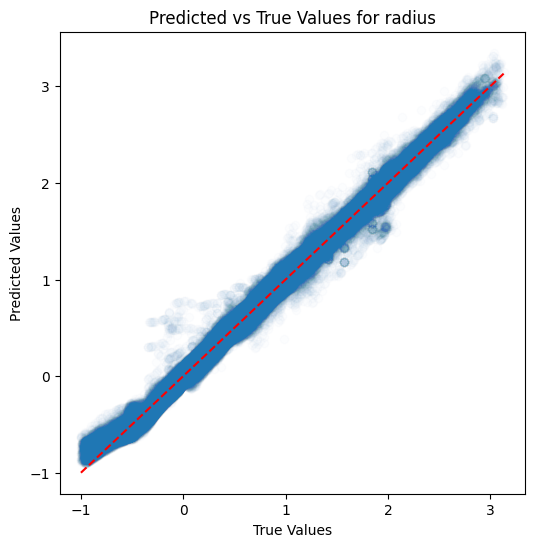

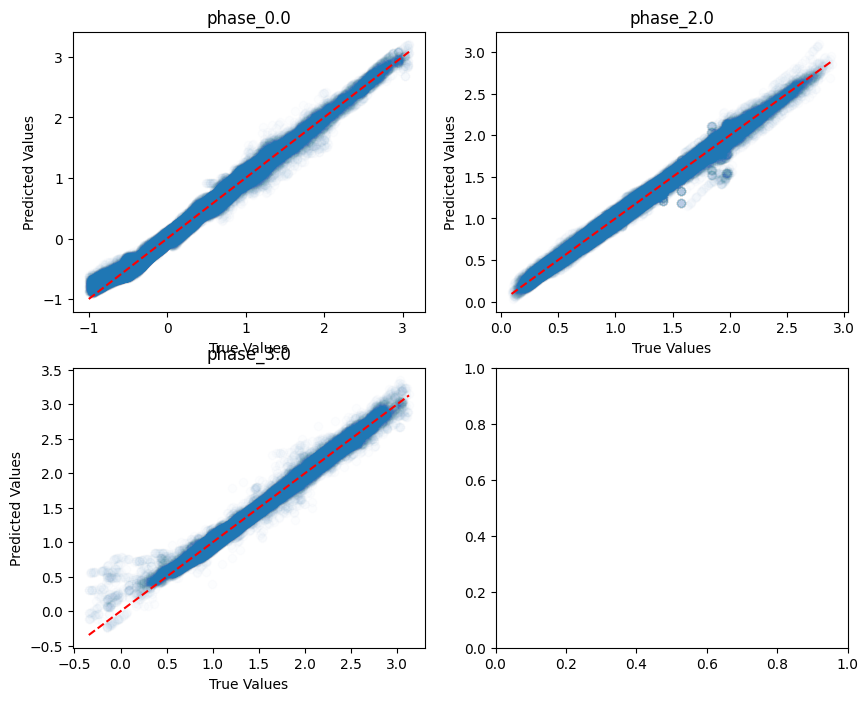

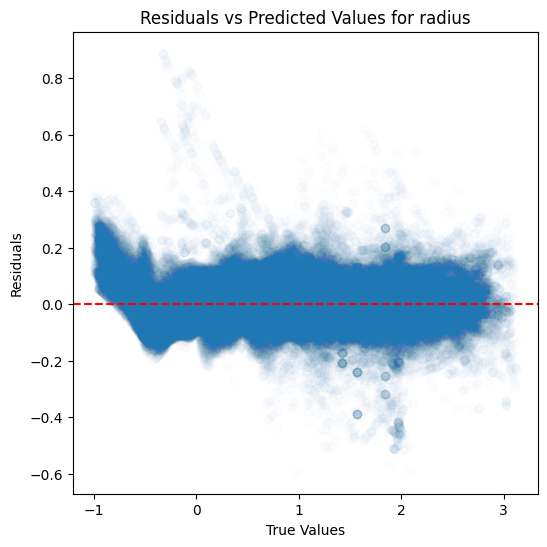

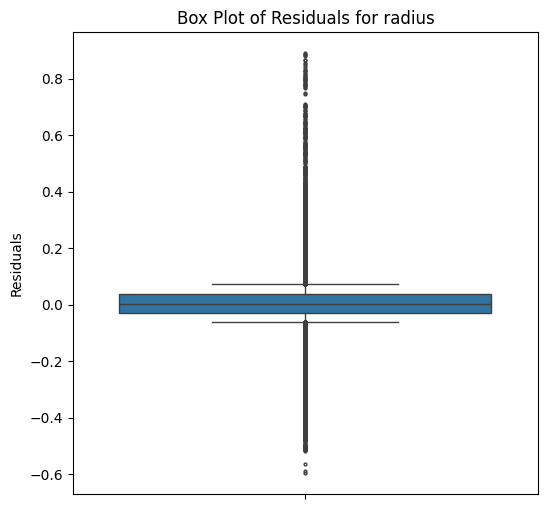

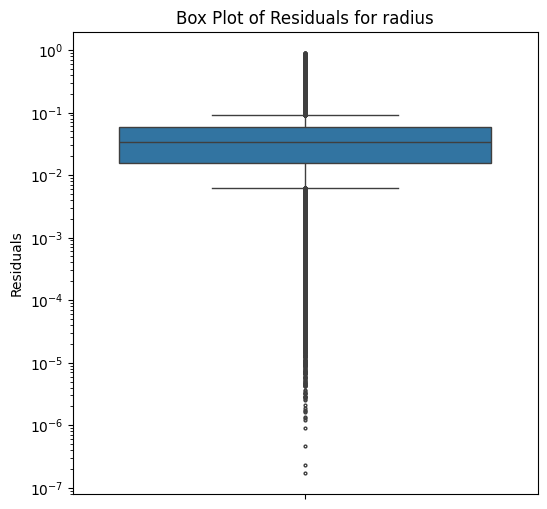

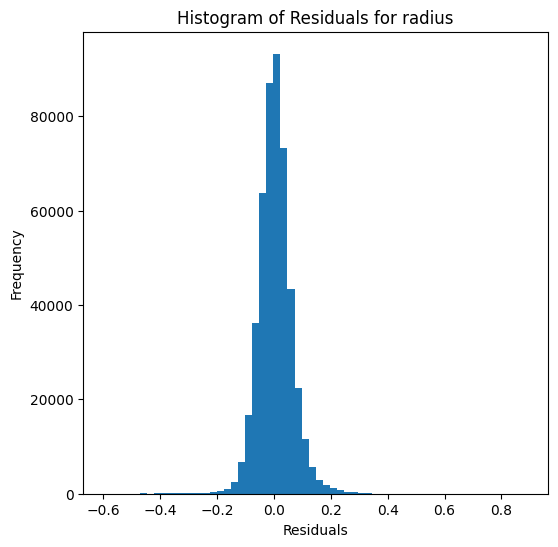

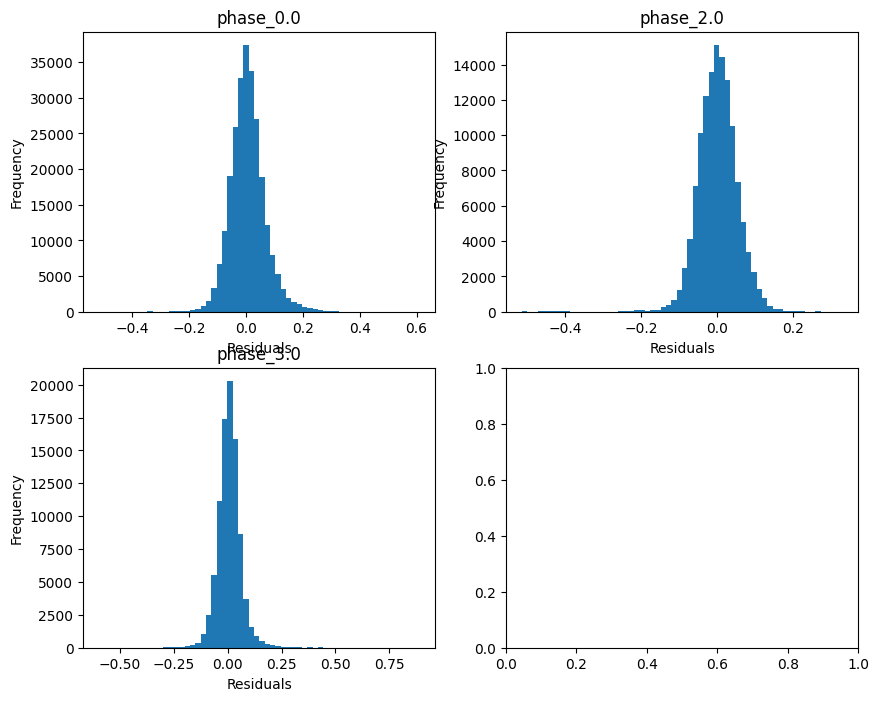

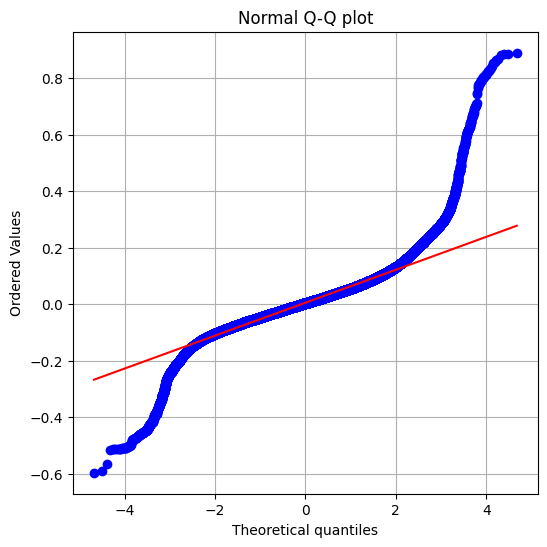

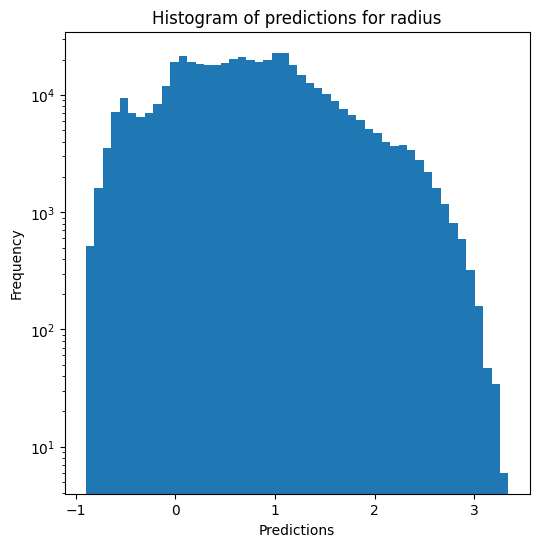

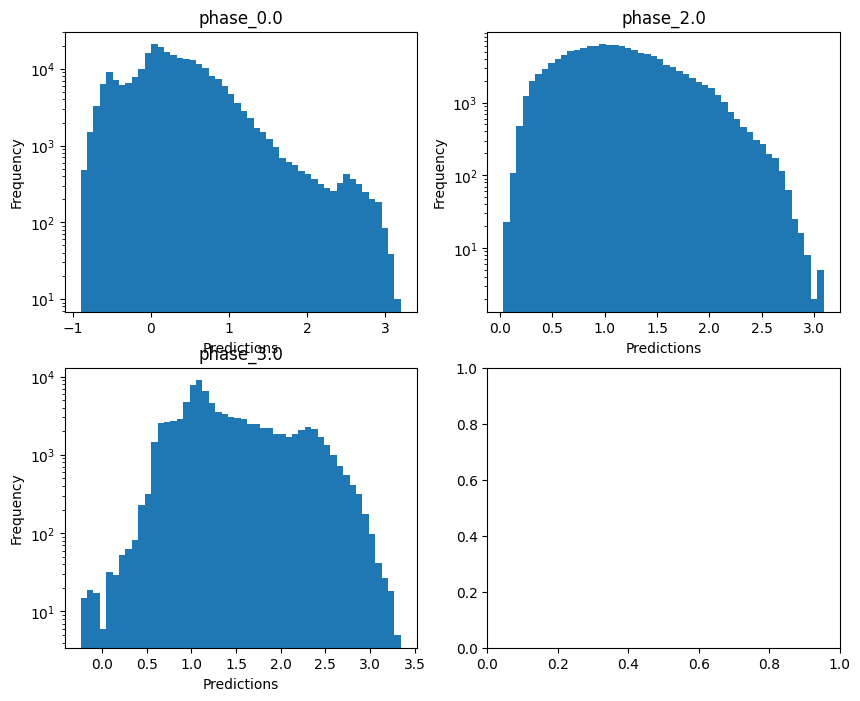

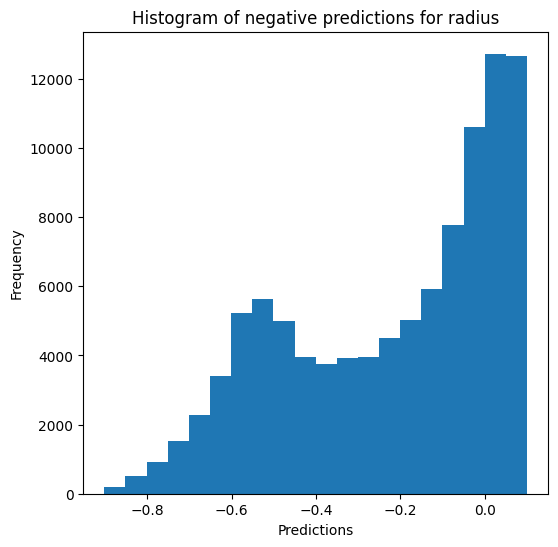

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, scaler_name=scaler_name, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon